In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.stats import ttest_rel, wilcoxon, t as tdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.svm import SVC

import importlib, phon_helpers, report_helpers
importlib.reload(phon_helpers); importlib.reload(report_helpers)
from phon_helpers import (manner, place, voicing, cv, vowel_length, vowel_place, is_cons,
                          gather_sequences, needleman_wunsch, edit_distance,
                          subs_position_zip, subs_nw, aligned_pairs_zip, aligned_pairs_nw,
                          feature_z, confusion_stats, phone_feat_dist)
from report_helpers import (phoneme_separability, decision_region_plot,
                            decision_region_pair, hg_amplitude_plot, error_structure_grid,
                            feature_panel, feature_separability_panel, separability_structure_grid,
                            feature_separability_grid)
from config import DUTCH_30_PATH

RESULTS = 'results'
FIGDIR  = 'report'; os.makedirs(FIGDIR, exist_ok=True)
PIDS    = [f'P{i:02d}' for i in range(21, 31)]      # sentence patients
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

def savefig(name): plt.savefig(os.path.join(FIGDIR, name)); print('saved', name)
def ci95(v): v = np.asarray(v); return v.mean(), 1.96 * v.std(ddof=1) / np.sqrt(len(v))
C_CRF, C_SSL = '#e08a2b', '#3b6fb0'
print("imports OK | data:", DUTCH_30_PATH)

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch
imports OK | data: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients


In [2]:
# Cell 1 — load saved results + features
def _load(name):
    p = os.path.join(RESULTS, name)
    if not os.path.exists(p):
        print(f"  [missing] {name}"); return None
    with open(p, 'rb') as f: return pickle.load(f)

crf_export   = _load('crf_export.pkl')
ssl_results  = _load('ssl_results.pkl')
crf_perclass = _load('crf_perpatient_perclass.pkl')
ssl_perclass = _load('ssl_perpatient_perclass.pkl')
crf_vpairs   = _load('crf_vowelpairs.pkl')
ssl_vpairs   = _load('ssl_vowelpairs.pkl')
crf_feats    = _load('crf_feats.pkl')
ssl_feats    = _load('ssl_feats.pkl')

def get_feats(model, pid):
    d = (crf_feats if model == 'crf' else ssl_feats)[pid]
    return np.asarray(d['X'], np.float32), np.asarray(d['y']), np.asarray(d['sid'])

pids = sorted(set(crf_export) & set(ssl_results)) if (crf_export and ssl_results) else PIDS
print("patients:", pids)

  [missing] crf_export.pkl
  [missing] ssl_results.pkl
  [missing] crf_perpatient_perclass.pkl
  [missing] ssl_perpatient_perclass.pkl
  [missing] crf_vowelpairs.pkl
  [missing] ssl_vowelpairs.pkl
  [missing] crf_feats.pkl
patients: ['P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']


### Features

In [3]:
amp = hg_amplitude_plot(crf_feats, title='CRF per-phoneme HG amplitude')

AttributeError: 'NoneType' object has no attribute 'items'

### Phoneme Separability

In [3]:
import numpy as np, matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, silhouette_score

def phoneme_separability(X, y, grp=None, title='', top_k=12, min_count=25, n_pca=50, n_splits=5):
    X = np.asarray(X); y = np.asarray(y)
    keep = [c for c, n in Counter(y).items() if n >= min_count]
    m = np.isin(y, keep); X, y = X[m], y[m]
    grp = np.asarray(grp)[m] if grp is not None else None
    classes = sorted(set(y)); cidx = {c: i for i, c in enumerate(classes)}

    # ---------- HONEST: cross-validated per-class one-vs-rest AUC ----------
    if grp is not None:
        splits = list(GroupKFold(n_splits).split(X, y, grp))     # prevents same-sentence leakage
    else:
        print("  [warn] no grp passed -> StratifiedKFold; same-sentence leakage NOT prevented")
        splits = list(StratifiedKFold(n_splits, shuffle=True, random_state=0).split(X, y))
    steps = [StandardScaler()]
    if X.shape[1] > n_pca: steps.append(PCA(n_components=n_pca, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    clf = make_pipeline(*steps)
    proba = np.zeros((len(y), len(classes)))
    for tr, te in splits:
        clf.fit(X[tr], y[tr]); p = clf.predict_proba(X[te])
        for j, c in enumerate(clf.classes_):
            if c in cidx: proba[te, cidx[c]] = p[:, j]
    ovr = {c: roc_auc_score((y == c).astype(int), proba[:, cidx[c]])
           for c in classes if 0 < (y == c).sum() < len(y)}
    macro = np.mean(list(ovr.values()))

    # ---------- descriptive: standardized centroids + silhouette (in-sample, unsupervised) ----------
    Xs = StandardScaler().fit_transform(X)
    Xp = PCA(n_components=min(n_pca, Xs.shape[1], Xs.shape[0] - 1)).fit_transform(Xs)
    sil = silhouette_score(Xp, y)
    C = np.array([Xs[y == c].mean(0) for c in classes])
    Cn = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-9)
    S = Cn @ Cn.T
    print(f"{title}:  n={len(y)} classes={len(classes)} | "
          f"macro OvR AUC={macro:.3f}  max={max(ovr.values()):.3f}  "
          f"#>0.7={sum(a > 0.7 for a in ovr.values())} | silhouette={sil:.3f}")

    # ---------- HONEST held-out LDA(2) projection (train-fit, test-plotted) ----------
    tr, te = splits[0]
    proj = make_pipeline(StandardScaler(),
                         PCA(n_components=min(n_pca, X.shape[1]), random_state=0),
                         LinearDiscriminantAnalysis(n_components=2)).fit(X[tr], y[tr])
    Z = proj.transform(X[te]); yte = y[te]
    top = [c for c, _ in Counter(y).most_common(top_k) if c in classes]

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))
    im = ax[0].imshow(S, cmap='viridis', vmin=-1, vmax=1)
    ax[0].set_xticks(range(len(classes))); ax[0].set_xticklabels(classes, rotation=90, fontsize=7)
    ax[0].set_yticks(range(len(classes))); ax[0].set_yticklabels(classes, fontsize=7)
    ax[0].set_title(f"{title}\ncentroid cosine (bright off-diag = look-alike)", fontsize=10)
    plt.colorbar(im, ax=ax[0], fraction=0.046)

    cmap = plt.get_cmap('tab20')
    for i, c in enumerate(top):
        mm = yte == c
        ax[1].scatter(Z[mm, 0], Z[mm, 1], s=12, alpha=0.55, color=cmap(i % 20), label=str(c))
    ax[1].set_title(f"{title}\nHELD-OUT LDA(2)", fontsize=10)
    ax[1].legend(fontsize=7, ncol=2, markerscale=2)

    ph = sorted(ovr, key=lambda c: -ovr[c])
    ax[2].bar(range(len(ph)), [ovr[c] for c in ph], color='#3b6fb0')
    ax[2].axhline(0.7, color='r', ls='--', lw=0.8); ax[2].axhline(0.5, color='k', ls=':', lw=0.8)
    ax[2].set_xticks(range(len(ph))); ax[2].set_xticklabels(ph, rotation=90, fontsize=7)
    ax[2].set_ylabel('cross-validated OvR AUC')
    ax[2].set_title(f"{title}\nper-phoneme separability", fontsize=10)
    plt.tight_layout(); plt.show()
    return dict(macro_auc=float(macro), max_auc=float(max(ovr.values())),
                n_above_0p7=int(sum(a > 0.7 for a in ovr.values())),
                silhouette=float(sil), per_class=ovr, n=len(y), n_classes=len(classes))

CRF P22 (stacked-HG):  n=3251 classes=27 | macro OvR AUC=0.631  max=0.791  #>0.7=4 | silhouette=-0.115


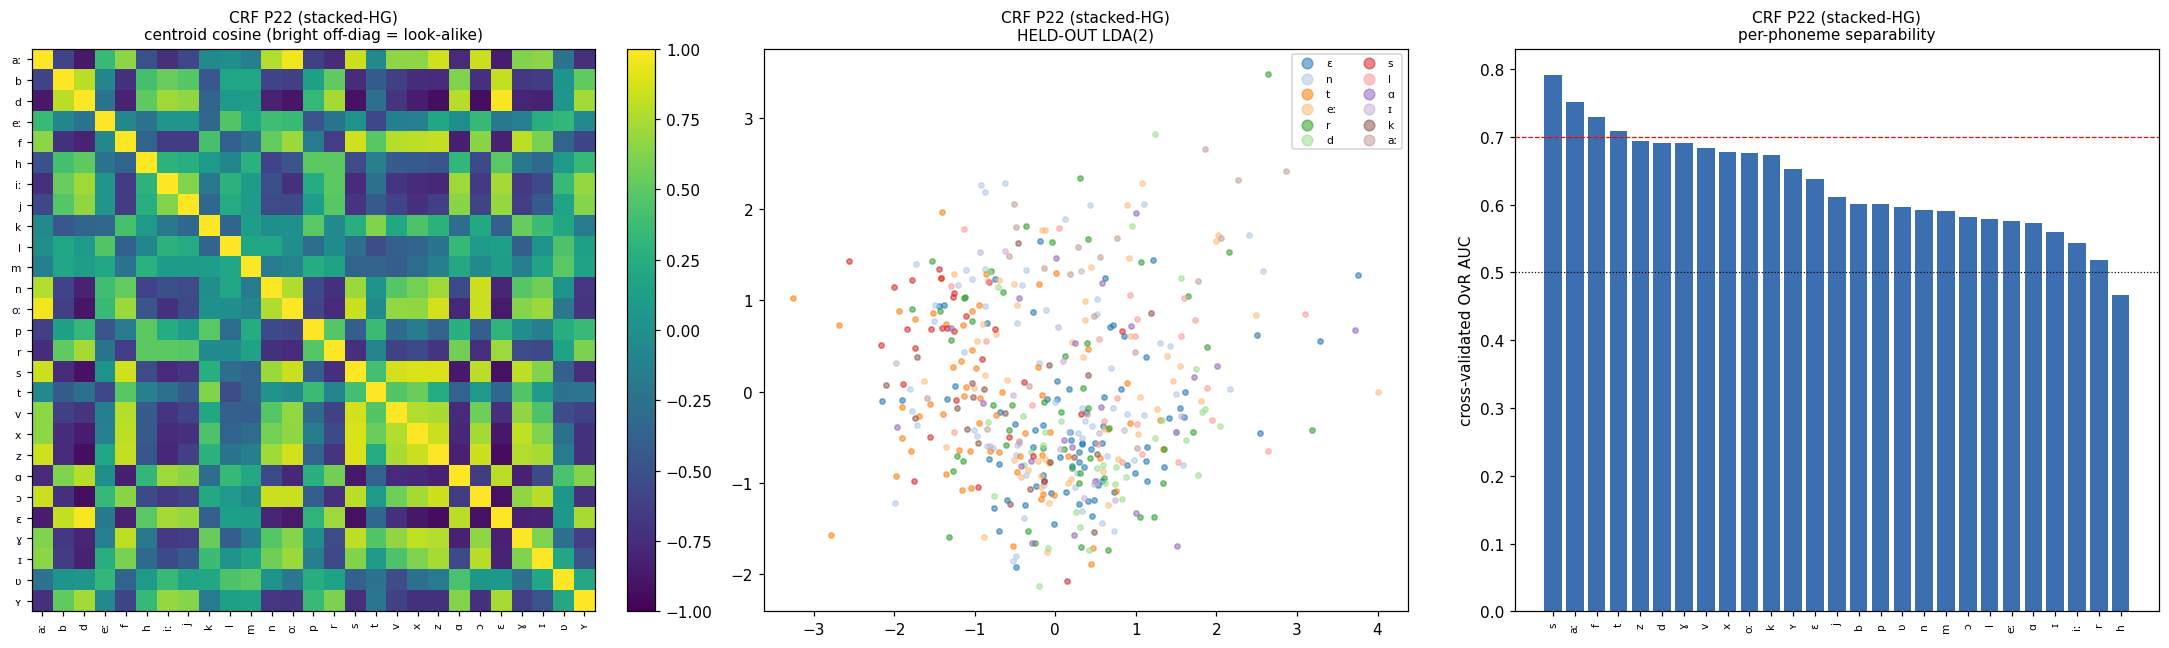

SSL P22 (128-d emb):  n=3251 classes=27 | macro OvR AUC=0.582  max=0.721  #>0.7=2 | silhouette=-0.067


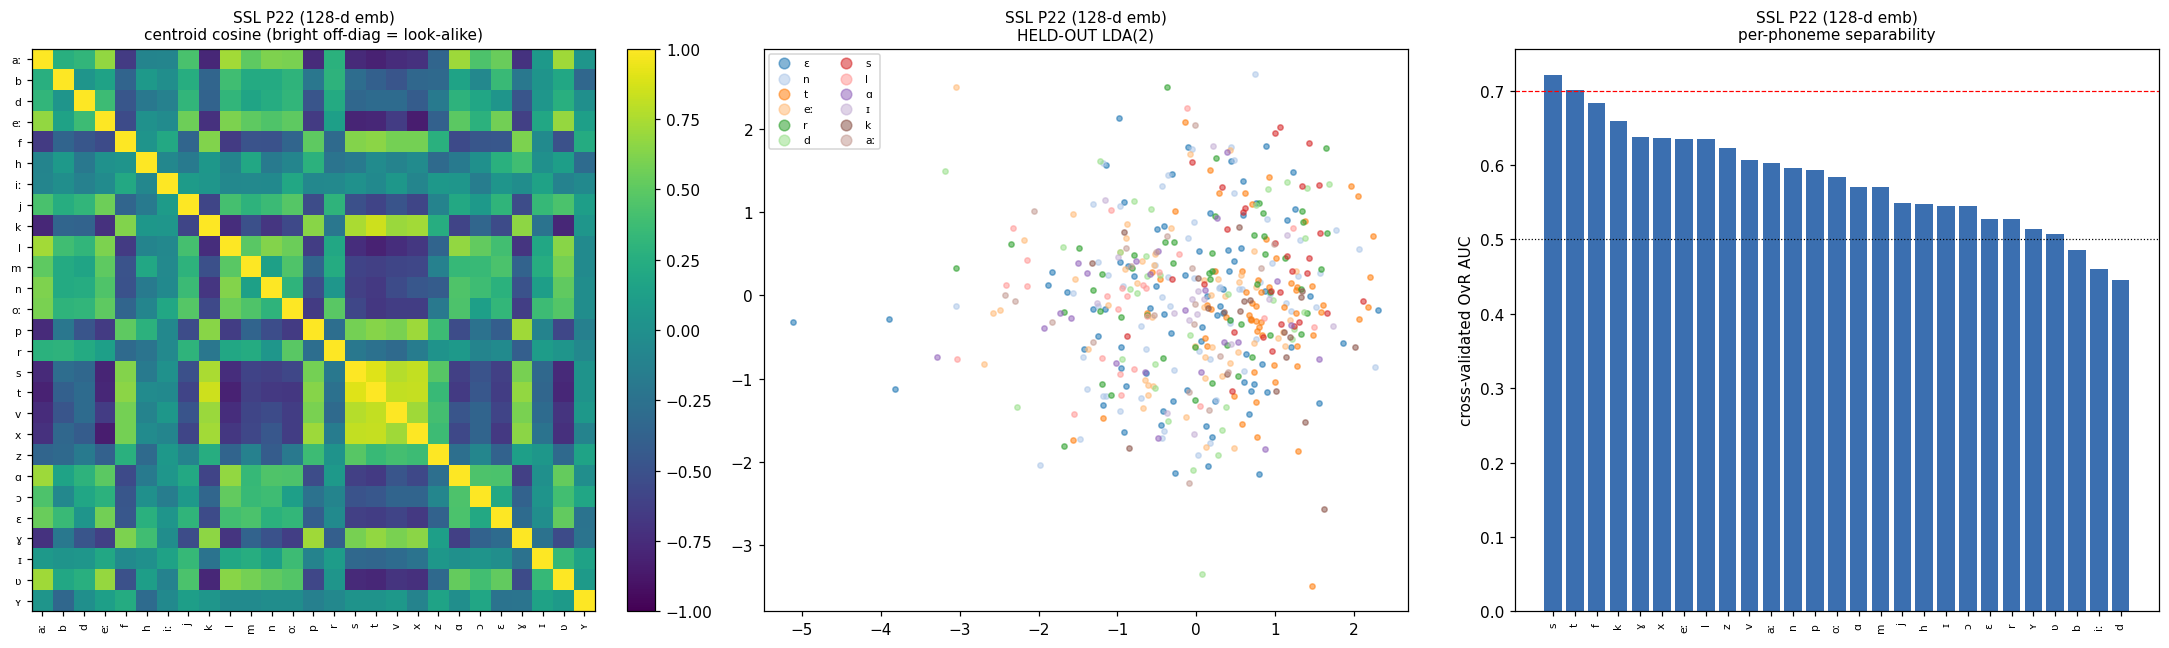

In [5]:
res_crf = phoneme_separability(*get_feats('crf', 'P22'), title='CRF P22 (stacked-HG)')
res_ssl = phoneme_separability(*get_feats('ssl', 'P22'), title='SSL P22 (128-d emb)')

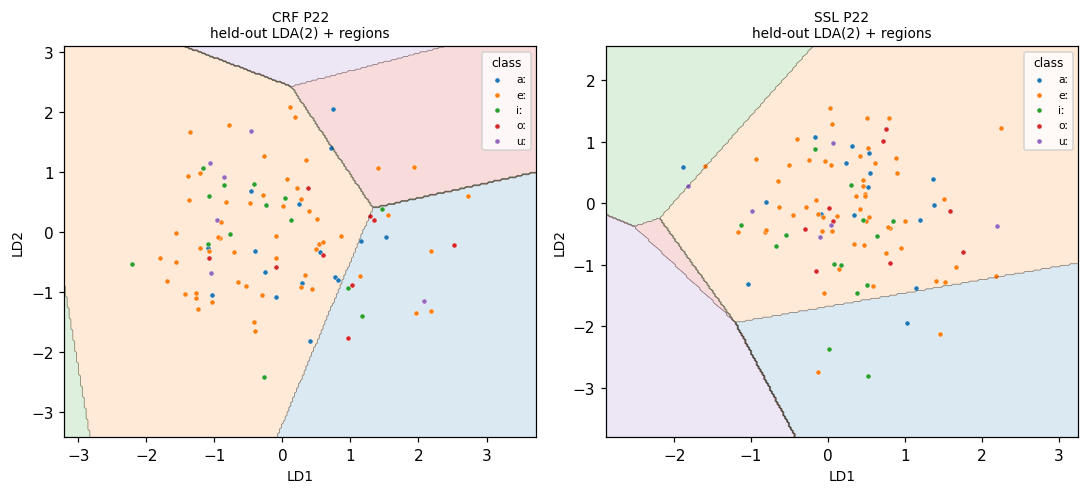

In [6]:
# decision_region_plot(*get_feats('crf', 'P22'), title='CRF P22', proj='lda')
# decision_region_plot(*get_feats('ssl', 'P22'), title='SSL P22', proj='lda')   # proj='pca' for the conservative version
decision_region_pair(get_feats, 'P22', proj='lda')

In [44]:
import numpy as np, pickle
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

def phoneme_auc_perclass(X, y, grp, min_count=25, n_splits=5, n_pca=50):
    y, grp = np.asarray(y), np.asarray(grp)
    classes = sorted(c for c, n in Counter(y).items() if n >= min_count)
    keep = np.isin(y, classes); X, y, grp = np.asarray(X)[keep], y[keep], grp[keep]
    cidx = {c: i for i, c in enumerate(classes)}
    proba = np.zeros((len(y), len(classes)))
    steps = [StandardScaler()]
    if n_pca and X.shape[1] > n_pca:
        steps.append(PCA(n_components=n_pca, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    clf = make_pipeline(*steps)
    for tr, te in GroupKFold(n_splits).split(X, y, grp):
        clf.fit(X[tr], y[tr]); p = clf.predict_proba(X[te])
        for j, c in enumerate(clf.classes_):
            if c in cidx: proba[te, cidx[c]] = p[:, j]
    per = {}
    for c in classes:
        yb = (y == c).astype(int)
        if 0 < yb.sum() < len(yb):
            per[c] = roc_auc_score(yb, proba[:, cidx[c]])
    return per

crf_feats = pickle.load(open('results/crf_feats.pkl', 'rb'))
ssl_feats = pickle.load(open('results/ssl_feats.pkl', 'rb'))

def per_patient(feats):
    return {pid: phoneme_auc_perclass(np.asarray(d['X'], np.float32),
                                      np.asarray(d['y']),
                                      np.asarray(d['sid']).astype(int),
                                      min_count=25, n_pca=50)
            for pid, d in feats.items()}

pickle.dump(per_patient(crf_feats), open('results/crf_perpatient_perclass.pkl', 'wb'))
pickle.dump(per_patient(ssl_feats), open('results/ssl_perpatient_perclass.pkl', 'wb'))

In [45]:
# Tail-separability test: is the CRF representation more separable than the SSL
# one for its BEST phonemes? (The cohort MEAN AUC is tied ~0.54, so we probe the
# TAIL instead — the single best phoneme, and how many phonemes clear a "well-
# separated" bar.) Patient is the unit: paired t-test across the 10 patients.
# Requires crf/ssl per-class AUCs built with the phoneme_auc_perclass function (PCA 50, min_count 25) 

from scipy.stats import ttest_rel
crf = pickle.load(open('results/crf_perpatient_perclass.pkl', 'rb'))
ssl = pickle.load(open('results/ssl_perpatient_perclass.pkl', 'rb'))
pids = sorted(set(crf) & set(ssl))
# --- Metric 1: best-phoneme AUC per patient (the top of the tail) ------------
cmax = np.array([max(crf[p].values()) for p in pids]); smax = np.array([max(ssl[p].values()) for p in pids])
smax = np.array([max(ssl[p].values()) for p in pids]) 

# --- Metric 2: how many phonemes each patient separates well (AUC > 0.7) ------
cn07 = np.array([sum(a > 0.7 for a in crf[p].values()) for p in pids])
sn07 = np.array([sum(a > 0.7 for a in ssl[p].values()) for p in pids]) 

# --- Report each metric: per-patient values, cohort mean, and the paired test -
# ttest_rel(cmax, smax) pairs CRF vs SSL within each patient and tests whether
# the per-patient differences are reliably non-zero across the cohort.
print("max AUC  CRF", cmax.round(2), "mean", cmax.mean().round(3))
print("         SSL", smax.round(2), "mean", smax.mean().round(3),
      " paired-t p =", round(ttest_rel(cmax, smax)[1], 4))   # CRF best vs SSL best
print("#>0.7    CRF", cn07, "mean", cn07.mean())
print("         SSL", sn07, "mean", sn07.mean(),
      " paired-t p =", round(ttest_rel(cn07, sn07)[1], 4))    # CRF #well-sep vs SSL #well-sep

max AUC  CRF [0.71 0.79 0.68 0.74 0.83 0.82 0.71 0.83 0.76 0.78] mean 0.765
         SSL [0.6  0.72 0.68 0.66 0.6  0.67 0.62 0.67 0.69 0.68] mean 0.66  paired-t p = 0.0003
#>0.7    CRF [1 4 0 1 2 2 2 3 2 3] mean 2.0
         SSL [0 2 0 0 0 0 0 0 0 0] mean 0.2  paired-t p = 0.0002


CRF's representation separates its best phonemes reliably better than SSL's.

In [46]:
# Which phoneme is each patient's BEST (the one driving max AUC)?
print("CRF best phoneme per patient:")
for p in pids:
    best = max(crf[p], key=crf[p].get)
    print(f"  {p}: {best}  (AUC {crf[p][best]:.2f})")

# Which phonemes clear 0.7, pooled across patients?
from collections import Counter
above = Counter()
for p in pids:
    for ph, a in crf[p].items():
        if a > 0.7: above[ph] += 1
print("\nphonemes with AUC>0.7 (count of patients):", above.most_common())

CRF best phoneme per patient:
  P21: b  (AUC 0.71)
  P22: s  (AUC 0.79)
  P23: aː  (AUC 0.68)
  P24: aː  (AUC 0.74)
  P25: aː  (AUC 0.83)
  P26: aː  (AUC 0.82)
  P27: aː  (AUC 0.71)
  P28: oː  (AUC 0.83)
  P29: aː  (AUC 0.76)
  P30: oː  (AUC 0.78)

phonemes with AUC>0.7 (count of patients): [(np.str_('aː'), 8), (np.str_('oː'), 4), (np.str_('s'), 3), (np.str_('b'), 1), (np.str_('f'), 1), (np.str_('t'), 1), (np.str_('ʋ'), 1), (np.str_('d'), 1)]


In [47]:
from collections import defaultdict
import numpy as np
def agg(pp):
    aucs = defaultdict(list)
    for d in pp.values():
        for ph, a in d.items(): aucs[ph].append(a)
    return {ph: (np.mean(v), sum(a > 0.7 for a in v), len(v)) for ph, v in aucs.items()}
ca, sa = agg(crf), agg(ssl)
print(f"{'ph':<4}{'CRFμ':>8}{'>0.7':>8}{'SSLμ':>8}{'>0.7':>8}{' #patients with phoneme >= min count':>5}")
for ph in sorted(ca, key=lambda p: -ca[p][0])[:15]:
    sm, sn, _ = sa.get(ph, (np.nan, 0, 0))
    print(f"{ph:<4}{ca[ph][0]:>8.3f}{ca[ph][1]:>8}{sm:>8.3f}{sn:>8}{ca[ph][2]:>5}")

ph      CRFμ    >0.7    SSLμ    >0.7 #patients with phoneme >= min count
aː     0.748       8   0.595       0   10
oː     0.686       4   0.535       0   10
d      0.643       1   0.520       0   10
s      0.633       3   0.600       1   10
uː     0.624       0   0.563       0    1
b      0.619       1   0.521       0   10
ɑ      0.605       0   0.586       0   10
ʋ      0.598       1   0.540       0   10
ɔ      0.590       0   0.560       0   10
k      0.581       0   0.540       0   10
t      0.580       1   0.575       1   10
ɣ      0.572       0   0.522       0   10
ɛ      0.563       0   0.501       0   10
h      0.562       0   0.559       0   10
z      0.557       0   0.575       0   10


In [52]:
import itertools, numpy as np
# pair_auc must be defined/imported here (PCA 50, to match CRF)
LONG = ['aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː']
crf_feats = {p: {**d, 'X': np.asarray(d['X'], np.float32)}
             for p, d in pickle.load(open('results/crf_feats.pkl', 'rb')).items()}
def long_pairwise(feats):
    rows = []
    for a, b in itertools.combinations(LONG, 2):
        vals = [pair_auc(d['X'], d['y'], d['sid'], a, b) for d in feats.values()]
        vals = [v for v in vals if np.isfinite(v)]
        if len(vals) >= 5: rows.append((f"{a}-{b}", float(np.mean(vals)), len(vals)))
    return sorted(rows, key=lambda r: -r[1])

for nm, m, n in long_pairwise(ssl_feats): print(f"{nm:10} SSL {m:.3f} (n={n})")
print("SSL mean:", np.mean([m for _, m, _ in long_pairwise(ssl_feats)]).round(3))
print("CRF mean:", np.mean([m for _, m, _ in long_pairwise(crf_feats)]).round(3))

aː-eː      SSL 0.586 (n=10)
eː-uː      SSL 0.565 (n=10)
iː-oː      SSL 0.547 (n=10)
aː-iː      SSL 0.544 (n=10)
aː-uː      SSL 0.527 (n=10)
eː-oː      SSL 0.524 (n=10)
aː-oː      SSL 0.508 (n=10)
oː-uː      SSL 0.504 (n=10)
aː-yː      SSL 0.489 (n=9)
eː-iː      SSL 0.486 (n=10)
uː-yː      SSL 0.470 (n=9)
oː-yː      SSL 0.468 (n=9)
iː-yː      SSL 0.456 (n=9)
iː-uː      SSL 0.455 (n=10)
eː-yː      SSL 0.412 (n=9)
SSL mean: 0.503
CRF mean: 0.556


##### Duration matched long vowel pairwise AUC

In [100]:
import itertools, numpy as np
from scipy.stats import ttest_rel, wilcoxon

def per_patient_long(feats):
    out = {}
    for pid, d in feats.items():
        X = np.asarray(d['X'], np.float32)
        vals = [pair_auc(X, d['y'], d['sid'], a, b)
                for a, b in itertools.combinations(LONG, 2)]
        vals = [v for v in vals if np.isfinite(v)]
        if vals: out[pid] = float(np.mean(vals))
    return out

cp, sp = per_patient_long(crf_feats), per_patient_long(ssl_feats)
ids = sorted(set(cp) & set(sp))
c = np.array([cp[p] for p in ids]); s = np.array([sp[p] for p in ids])
print(f"by-patient  CRF {c.mean():.3f}  SSL {s.mean():.3f}  CRF>SSL {int((c>s).sum())}/{len(ids)}")
print(f"paired t p={ttest_rel(c,s).pvalue:.4g}   Wilcoxon p={wilcoxon(c,s).pvalue:.4g}")

by-patient  CRF 0.555  SSL 0.503  CRF>SSL 8/10
paired t p=0.03069   Wilcoxon p=0.02734


In [99]:
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel, wilcoxon

def macro_auc(d, min_count=25, n_pca=50, n_splits=5):
    """Full-inventory macro AUC, same probe as report.phoneme_separability.
    Returns (macro OvR, macro OvO) from one CV fit."""
    X = np.asarray(d['X'], np.float32); y = np.asarray(d['y']); g = np.asarray(d['sid'])
    classes = sorted(c for c, n in Counter(y).items() if n >= min_count)
    m = np.isin(y, classes); X, y, g = X[m], y[m], g[m]
    if len(classes) < 2 or len(set(g)) < n_splits: return np.nan, np.nan
    cidx = {c: i for i, c in enumerate(classes)}
    proba = np.zeros((len(y), len(classes)))
    steps = [StandardScaler()]
    if X.shape[1] > n_pca: steps.append(PCA(n_components=n_pca, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    clf = make_pipeline(*steps)
    for tr, te in GroupKFold(n_splits).split(X, y, g):
        clf.fit(X[tr], y[tr]); p = clf.predict_proba(X[te])
        for j, c in enumerate(clf.classes_):
            if c in cidx: proba[te, cidx[c]] = p[:, j]
    ovr = np.mean([roc_auc_score((y == c).astype(int), proba[:, cidx[c]])
                   for c in classes if 0 < (y == c).sum() < len(y)])
    P = proba.copy(); rs = P.sum(1, keepdims=True); rs[rs == 0] = 1; P /= rs
    ovo = roc_auc_score(y, P, multi_class='ovo', average='macro', labels=classes)
    return float(ovr), float(ovo)

print("Feature separability macro OvO")
rows = []
for pid in pids:
    cr = macro_auc(crf_feats[pid]); sr = macro_auc(ssl_feats[pid])
    rows.append((pid, *cr, *sr))
    print(f"{pid}: CRF OvR {cr[0]:.3f} OvO {cr[1]:.3f} | SSL OvR {sr[0]:.3f} OvO {sr[1]:.3f}")

A = np.array([r[1:] for r in rows])     # cols: CRF_OvR, CRF_OvO, SSL_OvR, SSL_OvO
print(f"\ncohort  CRF  OvR {A[:,0].mean():.3f}  OvO {A[:,1].mean():.3f}")
print(f"        SSL  OvR {A[:,2].mean():.3f}  OvO {A[:,3].mean():.3f}")
print(f"OvR  CRF>SSL {(A[:,0]>A[:,2]).sum()}/{len(A)}  t p={ttest_rel(A[:,0],A[:,2]).pvalue:.3g}  W p={wilcoxon(A[:,0],A[:,2]).pvalue:.3g}")
print(f"OvO  CRF>SSL {(A[:,1]>A[:,3]).sum()}/{len(A)}  t p={ttest_rel(A[:,1],A[:,3]).pvalue:.3g}  W p={wilcoxon(A[:,1],A[:,3]).pvalue:.3g}")

Feature separability macro OvO
P21: CRF OvR 0.551 OvO 0.550 | SSL OvR 0.507 OvO 0.508
P22: CRF OvR 0.631 OvO 0.632 | SSL OvR 0.582 OvO 0.580
P23: CRF OvR 0.576 OvO 0.576 | SSL OvR 0.535 OvO 0.535
P24: CRF OvR 0.550 OvO 0.549 | SSL OvR 0.520 OvO 0.518
P25: CRF OvR 0.577 OvO 0.578 | SSL OvR 0.514 OvO 0.514
P26: CRF OvR 0.586 OvO 0.586 | SSL OvR 0.551 OvO 0.548
P27: CRF OvR 0.555 OvO 0.554 | SSL OvR 0.507 OvO 0.507
P28: CRF OvR 0.592 OvO 0.593 | SSL OvR 0.559 OvO 0.559
P29: CRF OvR 0.572 OvO 0.572 | SSL OvR 0.546 OvO 0.545
P30: CRF OvR 0.578 OvO 0.578 | SSL OvR 0.546 OvO 0.544

cohort  CRF  OvR 0.577  OvO 0.577
        SSL  OvR 0.537  OvO 0.536
OvR  CRF>SSL 10/10  t p=1.14e-06  W p=0.00195
OvO  CRF>SSL 10/10  t p=1.07e-06  W p=0.00195


In [106]:
from collections import Counter
def perphone_ovr(d, min_count=25, n_pca=50):
    X=np.asarray(d['X'],np.float32); y=np.asarray(d['y']); g=np.asarray(d['sid'])
    classes=sorted(c for c,n in Counter(y).items() if n>=min_count)
    m=np.isin(y,classes); X,y,g=X[m],y[m],g[m]; cidx={c:i for i,c in enumerate(classes)}
    proba=np.zeros((len(y),len(classes)))
    steps=[StandardScaler()]
    if X.shape[1]>n_pca: steps.append(PCA(n_pca,random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr',shrinkage='auto'))
    clf=make_pipeline(*steps)
    for tr,te in GroupKFold(5).split(X,y,g):
        clf.fit(X[tr],y[tr]); p=clf.predict_proba(X[te])
        for j,c in enumerate(clf.classes_):
            if c in cidx: proba[te,cidx[c]]=p[:,j]
    return {c: roc_auc_score((y==c).astype(int), proba[:,cidx[c]]) for c in classes if 0<(y==c).sum()<len(y)}

best=Counter(); above=Counter()
for p in pids:
    ovr=perphone_ovr(crf_feats[p])
    if not ovr: continue
    best[max(ovr,key=ovr.get)]+=1
    for ph,a in ovr.items():
        if a>0.7: above[ph]+=1
print("best phoneme (patient count):", best.most_common(5))
print("phonemes >0.7 (patient count):", above.most_common(8))

best phoneme (patient count): [(np.str_('aː'), 6), (np.str_('oː'), 2), (np.str_('b'), 1), (np.str_('s'), 1)]
phonemes >0.7 (patient count): [(np.str_('aː'), 8), (np.str_('oː'), 4), (np.str_('s'), 3), (np.str_('b'), 1), (np.str_('f'), 1), (np.str_('t'), 1), (np.str_('ʋ'), 1), (np.str_('d'), 1)]


##### Duration

In [103]:
from phon_helpers import vowel_length      # 'long'/'short'; None for consonants

def duration_auc(d, n_pca=50, min_count=10):
    X = np.asarray(d['X'], np.float32); y = np.asarray(d['y']); g = np.asarray(d['sid'])
    lab = np.array([vowel_length(p) for p in y], dtype=object)
    m = np.array([l is not None for l in lab]); X, lab, g = X[m], lab[m].astype(str), g[m]
    keep = [c for c, n in Counter(lab).items() if n >= min_count]
    mm = np.isin(lab, keep); X, lab, g = X[mm], lab[mm], g[mm]
    cats = sorted(set(lab))
    if len(cats) < 2 or len(set(g)) < 5: return np.nan
    n_comp = min(n_pca, X.shape[1], int(0.8*len(X)) - 1)
    steps = [StandardScaler()]
    if X.shape[1] > n_comp: steps.append(PCA(n_comp, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    proba = cross_val_predict(make_pipeline(*steps), X, lab, cv=GroupKFold(5),
                              groups=g, method='predict_proba')
    return roc_auc_score((lab == cats[1]).astype(int), proba[:, 1])   # long vs short

cd = {p: duration_auc(d) for p, d in crf_feats.items()}
sd = {p: duration_auc(d) for p, d in ssl_feats.items()}
ids = [p for p in sorted(set(cd) & set(sd)) if np.isfinite(cd[p]) and np.isfinite(sd[p])]
c = np.array([cd[p] for p in ids]); s = np.array([sd[p] for p in ids])
print(f"duration (long vs short)  CRF {c.mean():.3f}  SSL {s.mean():.3f}  CRF>SSL {int((c>s).sum())}/{len(ids)}")
print(f"paired t p={ttest_rel(c,s).pvalue:.4g}  Wilcoxon p={wilcoxon(c,s).pvalue:.4g}  Δ={(c-s).mean():+.3f}")

duration (long vs short)  CRF 0.592  SSL 0.506  CRF>SSL 10/10
paired t p=3.865e-05  Wilcoxon p=0.001953  Δ=+0.086


CRF separates long vowels by quality significantly better than SSL. Per patient:  p ≈ 0.03, with t and Wilcoxon agreeing (0.031 vs 0.027) (not a single outlier patient driving test results)
by-pair test more significant (p ≈ 0.005)  because the 15 pairs aren't independent (vowels reused in different pairs)

##### Backness

In [101]:
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel, wilcoxon
from phon_helpers import vowel_place          # front/central/back; None for consonants

def backness_auc(d, n_pca=50, min_count=10):
    X = np.asarray(d['X'], np.float32); y = np.asarray(d['y']); g = np.asarray(d['sid'])
    lab = np.array([vowel_place(p) for p in y], dtype=object)
    m = np.array([l is not None for l in lab]); X, lab, g = X[m], lab[m].astype(str), g[m]
    keep = [c for c, n in Counter(lab).items() if n >= min_count]
    mm = np.isin(lab, keep); X, lab, g = X[mm], lab[mm], g[mm]
    cats = sorted(set(lab))
    if len(cats) < 2 or len(set(g)) < 5: return np.nan
    n_comp = min(n_pca, X.shape[1], int(0.8*len(X)) - 1)
    steps = [StandardScaler()]
    if X.shape[1] > n_comp: steps.append(PCA(n_comp, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    proba = cross_val_predict(make_pipeline(*steps), X, lab, cv=GroupKFold(5),
                              groups=g, method='predict_proba')
    if len(cats) == 2:
        return roc_auc_score((lab == cats[1]).astype(int), proba[:, 1])
    return roc_auc_score(lab, proba, multi_class='ovo', average='macro', labels=cats)

cb = {p: backness_auc(d) for p, d in crf_feats.items()}
sb = {p: backness_auc(d) for p, d in ssl_feats.items()}
ids = [p for p in sorted(set(cb) & set(sb)) if np.isfinite(cb[p]) and np.isfinite(sb[p])]
c = np.array([cb[p] for p in ids]); s = np.array([sb[p] for p in ids])
print(f"backness  CRF {c.mean():.3f}  SSL {s.mean():.3f}  CRF>SSL {int((c>s).sum())}/{len(ids)}")
print(f"paired t  p={ttest_rel(c, s).pvalue:.4g}   Wilcoxon p={wilcoxon(c, s).pvalue:.4g}")

backness  CRF 0.631  SSL 0.539  CRF>SSL 10/10
paired t  p=2.825e-06   Wilcoxon p=0.001953


CRF features are more distinguishable for vowel backness than SSL: 10.10 differences positive

In [105]:
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel, wilcoxon
from phon_helpers import manner, place, voicing, is_cons

def feat_sep_auc(d, fn, n_pca=50, min_count=10):
    X = np.asarray(d['X'], np.float32); y = np.asarray(d['y']); g = np.asarray(d['sid'])
    lab = np.array([fn(p) for p in y], dtype=object)
    m = np.array([l is not None for l in lab]); X, lab, g = X[m], lab[m].astype(str), g[m]
    keep = [c for c, n in Counter(lab).items() if n >= min_count]
    mm = np.isin(lab, keep); X, lab, g = X[mm], lab[mm], g[mm]
    cats = sorted(set(lab))
    if len(cats) < 2 or len(set(g)) < 5: return np.nan
    n_comp = min(n_pca, X.shape[1], int(0.8*len(X)) - 1)
    steps = [StandardScaler()]
    if X.shape[1] > n_comp: steps.append(PCA(n_comp, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    proba = cross_val_predict(make_pipeline(*steps), X, lab, cv=GroupKFold(5),
                              groups=g, method='predict_proba')
    if len(cats) == 2:
        return roc_auc_score((lab == cats[1]).astype(int), proba[:, 1])
    return roc_auc_score(lab, proba, multi_class='ovo', average='macro', labels=cats)

cons_manner = lambda p: manner(p) if is_cons(p) else None   # manner restricted to consonants
for name, fn in [('manner', cons_manner), ('place', place), ('voicing', voicing)]:
    cb = {p: feat_sep_auc(d, fn) for p, d in crf_feats.items()}
    sb = {p: feat_sep_auc(d, fn) for p, d in ssl_feats.items()}
    ids = [p for p in sorted(set(cb) & set(sb)) if np.isfinite(cb[p]) and np.isfinite(sb[p])]
    c = np.array([cb[p] for p in ids]); s = np.array([sb[p] for p in ids])
    print(f"{name:8} CRF {c.mean():.3f}  SSL {s.mean():.3f}  CRF>SSL {int((c>s).sum())}/{len(ids)}"
          f"   t p={ttest_rel(c, s).pvalue:.3g}   W p={wilcoxon(c, s).pvalue:.3g}")

manner   CRF 0.552  SSL 0.540  CRF>SSL 8/10   t p=0.0603   W p=0.084
place    CRF 0.542  SSL 0.534  CRF>SSL 6/10   t p=0.405   W p=0.557
voicing  CRF 0.573  SSL 0.567  CRF>SSL 7/10   t p=0.612   W p=0.375


No consonant-feature advantage
AUCs are all near chance 

In [57]:
import numpy as np
from collections import defaultdict
from scipy.stats import ttest_rel, wilcoxon
from phon_helpers import is_cons

cons_only = lambda pp: {p: {ph: a for ph, a in d.items() if is_cons(ph)} for p, d in pp.items()}
crf_c, ssl_c = cons_only(crf), cons_only(ssl)

# --- per-consonant table: mean AUC across patients, #patients>0.7, n ---
def agg(pp):
    a = defaultdict(list)
    for d in pp.values():
        for ph, v in d.items(): a[ph].append(v)
    return {ph: (np.mean(v), sum(x > 0.7 for x in v), len(v)) for ph, v in a.items()}
ca, sa = agg(crf_c), agg(ssl_c)
print(f"{'ph':4}{'CRFμ':>8}{'>0.7':>6}{'SSLμ':>8}{'>0.7':>6}{'n':>4}")
for ph in sorted(ca, key=lambda p: -ca[p][0]):
    sm, sn, _ = sa.get(ph, (np.nan, 0, 0))
    print(f"{ph:4}{ca[ph][0]:>8.3f}{ca[ph][1]:>6}{sm:>8.3f}{sn:>6}{ca[ph][2]:>4}")

# --- per-patient: best consonant + how many consonants clear 0.7 ---
pids = sorted(set(crf_c) & set(ssl_c))
cmax = np.array([max(crf_c[p].values()) for p in pids]); smax = np.array([max(ssl_c[p].values()) for p in pids])
cn07 = np.array([sum(a > 0.7 for a in crf_c[p].values()) for p in pids])
sn07 = np.array([sum(a > 0.7 for a in ssl_c[p].values()) for p in pids])
print(f"\nmax consonant AUC  CRF {cmax.mean():.3f}  SSL {smax.mean():.3f}"
      f"   paired-t p={ttest_rel(cmax, smax).pvalue:.3g}  W p={wilcoxon(cmax, smax).pvalue:.3g}")
print(f"#consonants>0.7    CRF mean {cn07.mean():.2f}  SSL mean {sn07.mean():.2f}")
print(f"   CRF per patient {cn07.tolist()}")
print(f"   SSL per patient {sn07.tolist()}")

ph      CRFμ  >0.7    SSLμ  >0.7   n
d      0.643     1   0.520     0  10
s      0.633     3   0.600     1  10
b      0.619     1   0.521     0  10
ʋ      0.598     1   0.540     0  10
k      0.581     0   0.540     0  10
t      0.580     1   0.575     1  10
ɣ      0.572     0   0.522     0  10
h      0.562     0   0.559     0  10
z      0.557     0   0.575     0  10
p      0.555     0   0.553     0  10
j      0.553     0   0.541     0  10
n      0.545     0   0.542     0  10
r      0.543     0   0.501     0  10
m      0.540     0   0.523     0  10
v      0.536     0   0.517     0  10
x      0.528     0   0.494     0  10
l      0.518     0   0.541     0  10
f      0.517     1   0.493     0   9

max consonant AUC  CRF 0.702  SSL 0.655   paired-t p=0.0115  W p=0.0195
#consonants>0.7    CRF mean 0.80  SSL mean 0.20
   CRF per patient [1, 3, 0, 0, 0, 1, 1, 1, 0, 1]
   SSL per patient [0, 2, 0, 0, 0, 0, 0, 0, 0, 0]


CRF is uniformly ~0.01–0.02 higher across consonants
plausibly a dimensionality effect, not a phonetic one. 

Consonant feature categories (manner, place, voicing) show no reliable difference between the representations. CRF's best consonant separates marginally better than SSL's (0.70 vs 0.66, p=0.01), but this is near chance, driven by the salient sibilant /s/ (the only consonant exceeding 0.7 in more than one patient, and available to both models), and reflects a small uniform separability offset consistent with the PCA-50 reduction rather than consonant-specific phonetic encoding. The CRF advantage is substantial and category-level only for vowels (quality and backness); for consonants it is weak, near-chance, and sibilant-driven.

In [104]:
# Consonant feature-separability contrasts (CRF vs SSL) — plosive is the test of interest
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pickle
from scipy.stats import ttest_rel, wilcoxon
import report_helpers as R

pids = sorted(set(crf_feats) & set(ssl_feats))

GROUPS = {
    'manner:plosive':   {'p','b','t','d','k','g'},
    'manner:fricative': {'f','v','s','z','x','ɣ','h'},
    'manner:nasal':     {'m','n','ŋ'},
    'manner:approx':    {'l','r','j','w','ʋ','ɥ'},
    'manner:sibilant':  {'s','z'},
    'place:labial':     {'p','b','m','f','v','ʋ','w'},   # bilabial + labiodental
    'place:alveolar':   {'t','d','s','z','n','l','r'},
    'place:velar':      {'k','g','x','ɣ','ŋ'},
}
alpha = 0.05 / len(GROUPS)            # Bonferroni over the 8 contrasts

def grp_auc(d, S):                    # binary group-vs-rest AUC for one patient
    return R._feat_auc(d, lambda p: 'in' if p in S else 'out')   # PCA50 + LDA, GroupKFold by sentence

print(f"{'contrast':>17} {'CRF':>6} {'SSL':>6} {'>SSL':>6} {'t p':>7} {'Wilcox':>7} {'Bonf':>4}")
print('-' * 62)
results = {'pids': pids, 'alpha_bonferroni': alpha}
for name, S in GROUPS.items():
    cz = np.array([grp_auc(crf_feats[p], S) for p in pids])
    sz = np.array([grp_auc(ssl_feats[p], S) for p in pids])
    ok = np.isfinite(cz) & np.isfinite(sz)
    tp = ttest_rel(cz[ok], sz[ok])[1]; wp = wilcoxon(cz[ok], sz[ok])[1]
    results[name] = dict(crf=cz, ssl=sz, t_p=float(tp), wilcoxon_p=float(wp),
                         crf_gt_ssl=int((cz[ok] > sz[ok]).sum()), n=int(ok.sum()))
    print(f"{name:>17} {np.nanmean(cz):6.3f} {np.nanmean(sz):6.3f} "
          f"{int((cz[ok] > sz[ok]).sum()):>3}/{ok.sum():<2} {tp:7.3f} {wp:7.3f} "
          f"{'*' if tp < alpha else '':>4}")
print('-' * 62)
print(f"Bonferroni alpha = {alpha:.4f}  ('*' = survives correction)")

pickle.dump(results, open('results/consonant_contrasts.pkl', 'wb'))   # reproducibility
print('saved results/consonant_contrasts.pkl')

         contrast    CRF    SSL   >SSL     t p  Wilcox Bonf
--------------------------------------------------------------
   manner:plosive  0.588  0.555   9/10   0.004   0.004    *
 manner:fricative  0.574  0.557   7/10   0.234   0.322     
     manner:nasal  0.533  0.538   4/10   0.308   0.275     
    manner:approx  0.531  0.521   5/10   0.432   0.770     
  manner:sibilant  0.629  0.591   7/10   0.134   0.160     
     place:labial  0.547  0.530   7/10   0.026   0.027     
   place:alveolar  0.551  0.544   4/10   0.445   0.846     
      place:velar  0.554  0.535   7/10   0.117   0.193     
--------------------------------------------------------------
Bonferroni alpha = 0.0063  ('*' = survives correction)
saved results/consonant_contrasts.pkl


In [15]:
import numpy as np
from scipy.stats import ttest_rel, t as tdist
from phon_helpers import gather_sequences, needleman_wunsch, cv
from sklearn.metrics import matthews_corrcoef

def cv_mcc_fair(out):                         # no is_crf — gap class penalizes over-generation
    gp, pp = gather_sequences(out); G, P = [], []
    for sid in set(gp) | set(pp):
        for g, p in needleman_wunsch(gp.get(sid, []), pp.get(sid, [])):
            G.append(cv(g) if g is not None else 'gap')
            P.append(cv(p) if p is not None else 'gap')
    return matthews_corrcoef(G, P)

crf_fair = np.array([cv_mcc_fair(crf_export[pid]) for pid in pids])
ssl_fair = np.array([cv_mcc_fair(ssl_results[pid]) for pid in pids])
d = crf_fair - ssl_fair; md = d.mean()
half = tdist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
print(f"fair C/V MCC: CRF={crf_fair.mean():.3f}  SSL={ssl_fair.mean():.3f}  "
      f"Δ={md:+.3f}  CI[{md-half:+.3f},{md+half:+.3f}]  p={ttest_rel(crf_fair, ssl_fair)[1]:.3g}")

fair C/V MCC: CRF=0.300  SSL=0.152  Δ=+0.148  CI[+0.119,+0.178]  p=1.23e-06


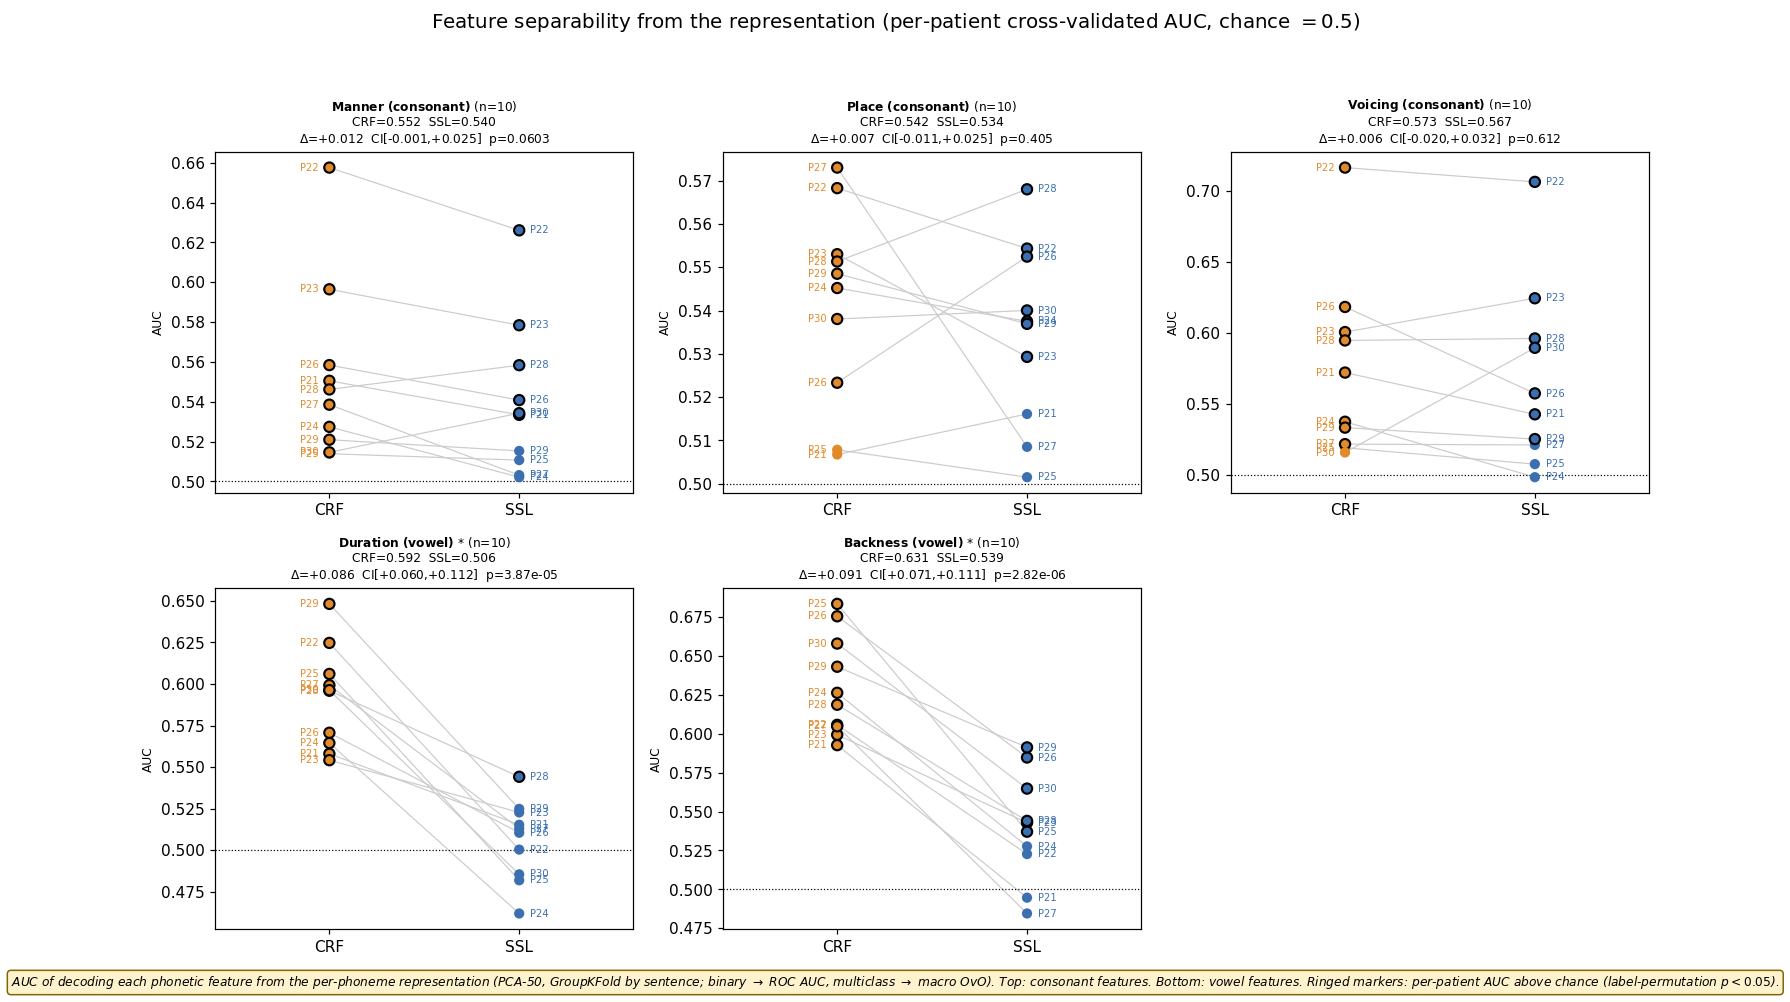

In [23]:
import importlib, report_helpers; importlib.reload(report_helpers)
from report_helpers import feature_separability_grid
feature_separability_grid(crf_feats, ssl_feats,
                          savepath='report/fig_feature_separability.png')   # n_perm=200 default

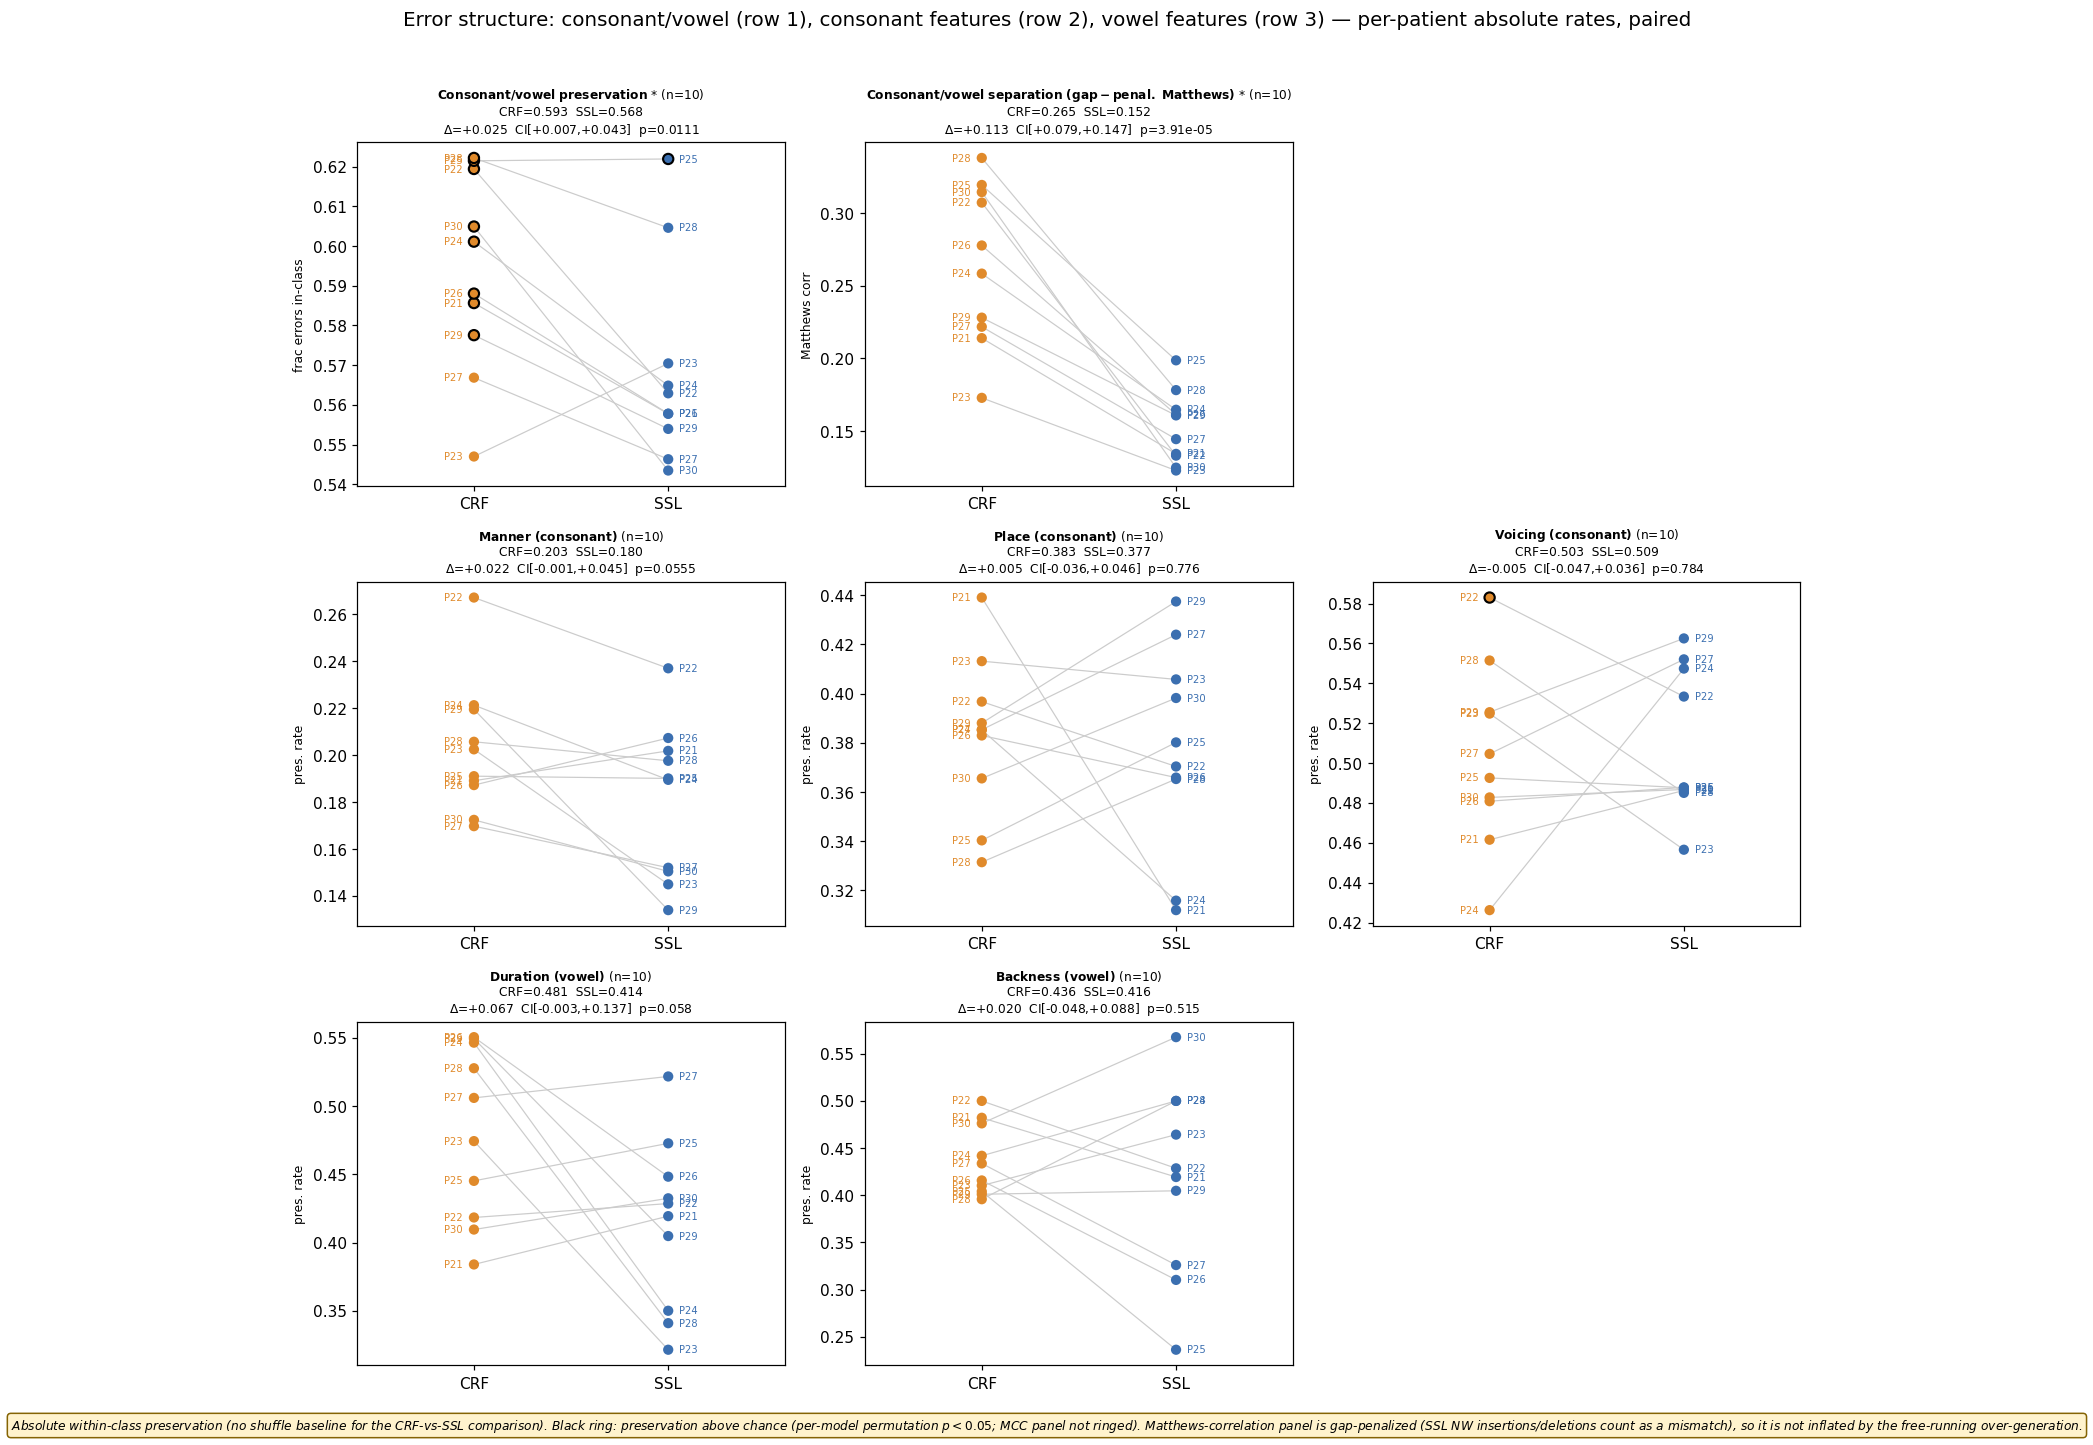

In [64]:
import importlib, report_helpers
importlib.reload(report_helpers)
from report_helpers import error_structure_grid
error_structure_grid(crf_export, ssl_results, savepath='report/fig_error_structure.png')

In [90]:
# %% Vowel-separability robustness sweep — n_pca × shrinkage (long-vowel pairwise AUC)
import itertools, numpy as np, pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel, wilcoxon

LONG = ['aː', 'eː', 'iː', 'oː', 'uː', 'yː', 'øː']

def pair_auc_cfg(X, y, sid, a, b, n_pca, shrinkage, n_splits=5):
    """Identical CV to MFA_CRF.pair_auc, but n_pca AND shrinkage are parameters.
    n_pca=None -> no PCA (raw standardized feats); shrinkage in {'auto', None, float}."""
    X = np.asarray(X, np.float32); y = np.asarray(y); sid = np.asarray(sid)
    m = (y == a) | (y == b)
    Xb, yb, gb = X[m], (y[m] == a).astype(int), sid[m]
    na, nb = int(yb.sum()), int(len(yb) - yb.sum())
    if na < 5 or nb < 5: return np.nan
    k = min(n_splits, len(set(gb)), na, nb)
    if k < 2: return np.nan
    steps = [StandardScaler()]
    if n_pca is not None:
        n_comp = min(n_pca, Xb.shape[1], int(0.7 * len(Xb)) - 1)
        if n_comp < 2: return np.nan
        steps.append(PCA(n_components=n_comp, random_state=0))
    steps.append(LinearDiscriminantAnalysis(solver='lsqr', shrinkage=shrinkage))
    try:
        score = cross_val_predict(make_pipeline(*steps), Xb, yb, groups=gb,
                                  cv=GroupKFold(n_splits=k), method='decision_function')
    except Exception:
        return np.nan
    return roc_auc_score(yb, score)

def by_patient_long(feats, n_pca, shrinkage):
    out = {}
    for pid, d in feats.items():
        vals = [pair_auc_cfg(d['X'], d['y'], d['sid'], a, b, n_pca, shrinkage)
                for a, b in itertools.combinations(LONG, 2)]
        vals = [v for v in vals if np.isfinite(v)]
        if vals: out[pid] = float(np.mean(vals))
    return out

def compare(n_pca, shrinkage):
    cp = by_patient_long(crf_feats, n_pca, shrinkage)
    sp = by_patient_long(ssl_feats, n_pca, shrinkage)
    ids = sorted(set(cp) & set(sp))
    c = np.array([cp[p] for p in ids]); s = np.array([sp[p] for p in ids])
    return dict(crf=c.mean(), ssl=s.mean(), delta=c.mean()-s.mean(),
                won=int((c > s).sum()), n=len(ids),
                t_p=ttest_rel(c, s).pvalue, w_p=wilcoxon(c, s).pvalue)

PCA_GRID  = [10, 20, 30, 50, 75, 100, None]    # None = no PCA
SHRINKAGE = ['auto', None]                      # 'auto' = Ledoit–Wolf; None = plain LDA

sweep = {}
for shr in SHRINKAGE:
    print(f"\n=== shrinkage={shr} ===")
    print(f"{'n_pca':>6}{'CRF':>8}{'SSL':>8}{'Δ':>8}{'CRF>SSL':>9}{'t p':>9}{'Wilcox':>9}")
    for npca in PCA_GRID:
        r = compare(npca, shr); sweep[(npca, str(shr))] = r
        print(f"{str(npca):>6}{r['crf']:>8.3f}{r['ssl']:>8.3f}{r['delta']:>+8.3f}"
              f"{r['won']:>6}/{r['n']:<2}{r['t_p']:>9.3g}{r['w_p']:>9.3g}")

pickle.dump(sweep, open('results/vowel_pca_sweep.pkl', 'wb'))
print('\nsaved results/vowel_pca_sweep.pkl')


=== shrinkage=auto ===
 n_pca     CRF     SSL       Δ  CRF>SSL      t p   Wilcox
    10   0.593   0.494  +0.099     9/10  0.00129  0.00586
    20   0.585   0.493  +0.091     9/10  0.00453   0.0137
    30   0.574   0.505  +0.070     9/10  0.00783   0.0137
    50   0.555   0.503  +0.052     8/10    0.031   0.0273
    75   0.543   0.503  +0.039     8/10   0.0571   0.0645
   100   0.542   0.501  +0.042     8/10   0.0601   0.0645
  None   0.525   0.510  +0.014     6/10    0.484    0.492

=== shrinkage=None ===
 n_pca     CRF     SSL       Δ  CRF>SSL      t p   Wilcox
    10   0.594   0.495  +0.099     9/10  0.00108  0.00586
    20   0.586   0.499  +0.088     9/10  0.00411   0.0137
    30   0.576   0.509  +0.067     9/10  0.00774   0.0137
    50   0.556   0.508  +0.048     9/10   0.0278   0.0195
    75   0.542   0.508  +0.034     8/10    0.076   0.0645
   100   0.541   0.505  +0.036     8/10   0.0778    0.084
  None   0.507   0.507  -0.000     5/10    0.999        1

saved results/vowel_pca

In [95]:
# %% Pretty display of the vowel-separability sweep (Jupyter)
import pickle, pandas as pd
sweep = pickle.load(open('results/vowel_pca_sweep.pkl', 'rb'))
PCA_GRID = [10, 20, 30, 50, 75, 100, None]

def row(npca):
    a = sweep[(npca, 'auto')]; n = sweep[(npca, 'None')]
    return [a['crf'], a['ssl'], a['delta'], a['t_p'],
            n['crf'], n['ssl'], n['delta'], n['t_p']]

idx  = [str(p) if p is not None else 'none' for p in PCA_GRID]
cols = pd.MultiIndex.from_product(
        [['shrinkage = auto (Ledoit–Wolf)', 'shrinkage = none'],
         ['CRF', 'SSL', 'Δ', 'p']])
df = pd.DataFrame([row(p) for p in PCA_GRID], index=idx, columns=cols)
df.index.name = 'n_PCA'

# --- formatting ---
fmt = {}
for shr in cols.levels[0]:
    fmt[(shr, 'CRF')] = '{:.3f}'.format
    fmt[(shr, 'SSL')] = '{:.3f}'.format
    fmt[(shr, 'Δ')]   = '{:+.3f}'.format
    fmt[(shr, 'p')]   = (lambda v: '<0.001' if v < 0.001 else f'{v:.3f}')

def colour_p(v):
    if v < 0.01:  return 'color:#1a7f37; font-weight:600'   # strong
    if v < 0.05:  return 'color:#1a7f37'                     # significant
    if v < 0.10:  return 'color:#9a6700'                     # marginal
    return 'color:#b0b0b0'                                   # n.s.

def colour_delta(v):
    return 'color:#1a7f37; font-weight:600' if v > 0.02 else ('color:#b0b0b0' if v < 0.01 else '')

p_cols = [(s, 'p') for s in cols.levels[0]]
d_cols = [(s, 'Δ') for s in cols.levels[0]]

styler = (df.style
    .format(fmt)
    .applymap(colour_p,     subset=p_cols)
    .applymap(colour_delta, subset=d_cols)
    .set_caption('Long-vowel pairwise AUC (CRF vs SSL) — robustness to PCA dimensionality and LDA shrinkage')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side:top; text-align:left; font-weight:600; font-size:13px; padding:6px 0 10px;'},
        {'selector': 'th.col_heading.level0',
         'props': 'text-align:center; border-bottom:1px solid #ccc; padding:4px 12px; font-size:12px;'},
        {'selector': 'th.col_heading.level1',
         'props': 'text-align:center; font-weight:500; font-size:12px; padding:3px 12px;'},
        {'selector': 'th.row_heading',
         'props': 'text-align:center; font-size:12px; font-weight:500;'},
        {'selector': 'td', 'props': 'text-align:right; font-size:12px; padding:3px 14px; font-variant-numeric:tabular-nums;'},
        {'selector': 'tbody tr:hover td', 'props': 'background:#f5f7fa;'},
    ])
    .set_properties(subset=[('shrinkage = auto (Ledoit–Wolf)', 'CRF')], **{'border-left': '1px solid #ddd'})
    .set_properties(subset=[('shrinkage = none', 'CRF')],               **{'border-left': '1px solid #ddd'})
)
styler

### Permutation Test

In [87]:
import pickle, numpy as np, scipy.stats as ss
ssl_crf = pickle.load(open('results/ssl_shift_perm_crfsplit.pkl', 'rb'))
crf     = pickle.load(open('results/crf_shift_perm.pkl', 'rb'))
print('SSL acc_pho mean z =', round(np.mean([r['z'] for r in ssl_crf['acc_pho'].values()]),3))  # expect ~2.65
print('SSL ce_pho  mean z =', round(np.mean([r['z'] for r in ssl_crf['ce_pho'].values()]),3))    # expect ~3.90

def summary(res):
    pids = sorted(res)
    p = np.clip([res[k]['p_one_sided'] for k in pids], 1e-300, 1.0)
    q = ss.false_discovery_control(p, method='bh')
    fisher = 1 - ss.chi2.cdf(-2*np.log(p).sum(), 2*len(p))
    zpos = sum(res[k]['z'] > 0 for k in pids)
    return int((q < 0.05).sum()), len(pids), fisher, zpos

print("\n=== per-phoneme, feature-rotation null ===")
print(f"{'metric':<10}{'model':<5}{'BH-FDR':>9}{'Fisher p':>12}{'z>0':>7}")
for metric in ['acc_pho', 'ce_pho']:
    for name, d in [('SSL', ssl_crf), ('CRF', crf)]:
        nsig, n, fp, zpos = summary(d[metric])
        print(f"{metric:<10}{name:<5}{nsig:>4}/{n:<4}{fp:>12.2e}{zpos:>4}/{n}")

# per-patient z side by side + paired test (SSL vs CRF)
print("\n=== per-patient z (SSL vs CRF) + paired test ===")
for metric in ['acc_pho', 'ce_pho']:
    sd, cd = ssl_crf[metric], crf[metric]
    pids = sorted(set(sd) & set(cd))
    sz = np.array([sd[p]['z'] for p in pids]); cz = np.array([cd[p]['z'] for p in pids])
    d = sz - cz
    print(f"\n{metric}:  {'pid':<5}{'SSL z':>8}{'CRF z':>8}")
    for p, a, b in zip(pids, sz, cz):
        print(f"      {p:<5}{a:+8.2f}{b:+8.2f}")
    t = ss.ttest_rel(sz, cz); w = ss.wilcoxon(sz, cz)
    print(f"   SSL>CRF {int((d>0).sum())}/{len(d)}  mean delta z={d.mean():+.2f}  "
          f"t p={t.pvalue:.3g}  Wilcoxon p={w.pvalue:.3g}")

SSL acc_pho mean z = 2.654
SSL ce_pho  mean z = 3.896

=== per-phoneme, feature-rotation null ===
metric    model   BH-FDR    Fisher p    z>0
acc_pho   SSL     6/10      2.99e-11   9/10
acc_pho   CRF     1/10      1.24e-01   4/10
ce_pho    SSL     7/10      8.66e-15  10/10
ce_pho    CRF     3/10      1.02e-03   6/10

=== per-patient z (SSL vs CRF) + paired test ===

acc_pho:  pid     SSL z   CRF z
      P21     +2.61   -0.86
      P22     +4.89   -0.10
      P23     +4.36   -0.86
      P24     +0.23   -0.70
      P25     +0.74   -0.53
      P26     +2.91   +3.13
      P27     -1.16   -1.12
      P28     +4.25   +0.53
      P29     +1.82   +2.20
      P30     +5.88   +0.32
   SSL>CRF 7/10  mean delta z=+2.45  t p=0.0101  Wilcoxon p=0.0273

ce_pho:  pid     SSL z   CRF z
      P21     +2.98   -1.22
      P22     +8.90   +2.67
      P23     +7.63   +0.21
      P24     +0.43   -0.07
      P25     +3.19   -1.05
      P26     +5.91   +4.00
      P27     +0.89   -0.97
      P28     +4.75   +0

#### PER/WER

In [88]:
# %% WER — closed-vocab, shared sentences only (fair), report notebook
import pickle, numpy as np
from collections import defaultdict, Counter
from scipy.stats import ttest_rel, t as tdist
from phon_helpers import needleman_wunsch, gather_sequences, edit_distance
from run_pipeline import load_mfa_alignments

crf_export  = pickle.load(open('results/crf_export.pkl', 'rb'))
ssl_results = pickle.load(open('results/ssl_results_crfsplit.pkl', 'rb'))
pids = sorted(set(crf_export) & set(ssl_results))

# lexicon + gold (phone,word) per sentence — from MFA, no `datasets` needed
gold_pw = {pid: {} for pid in pids}
word_prons = defaultdict(Counter)
for pid in pids:
    for sid, phs in load_mfa_alignments(pid).items():
        pw = [(ph['phone'], (ph['word'] or '').lower()) for ph in phs if ph.get('word')]
        gold_pw[pid][sid] = pw
        runs = []
        for i, (p, w) in enumerate(pw):
            if not runs or pw[i - 1][1] != w: runs.append([w, []])
            runs[-1][1].append(p)
        for w, ph in runs: word_prons[w][tuple(ph)] += 1
lexicon = {w: list(c.most_common(1)[0][0]) for w, c in word_prons.items()}
vocab = list(lexicon)
print(f"lexicon: {len(vocab)} words")

_cache = {}
def recognize(pred_str):
    key = tuple(pred_str)
    if key in _cache: return _cache[key]
    best, bd = None, 10**9
    for w in vocab:
        dd = edit_distance(key, lexicon[w])
        if dd < bd: bd, best = dd, w
    _cache[key] = best
    return best

def sentence_errors(pw, pred_phones):
    runs, run_of = [], {}
    for i, (p, w) in enumerate(pw):
        if not runs or pw[i - 1][1] != w: runs.append([w, []])
        runs[-1][1].append(i); run_of[i] = len(runs) - 1
    al = needleman_wunsch([g for g, _ in pw], pred_phones)
    per_run = defaultdict(list); gi = 0
    for g, p in al:
        if g is not None:
            if p is not None: per_run[run_of[gi]].append(p)
            gi += 1
    return sum(recognize(per_run.get(rid, [])) != w for rid, (w, _) in enumerate(runs)), len(runs)

def wer_on(out, pid, sids):
    _, pred_per = gather_sequences(out); W = N = 0
    for sid in sids:
        if sid in pred_per and sid in gold_pw[pid]:
            w, n = sentence_errors(gold_pw[pid][sid], pred_per[sid]); W += w; N += n
    return (W / N if N else np.nan), N

crf_w, ssl_w = {}, {}
print(f"\n{'pid':4} | shared_sents | shared_words | CRF WER | SSL WER")
for pid in pids:
    _, cpred = gather_sequences(crf_export[pid])
    _, spred = gather_sequences(ssl_results[pid])
    shared = set(cpred) & set(spred) & set(gold_pw[pid])
    cw, nw_words = wer_on(crf_export[pid], pid, shared)
    sw, _        = wer_on(ssl_results[pid], pid, shared)
    crf_w[pid], ssl_w[pid] = cw, sw
    print(f"{pid:4} | {len(shared):11} | {nw_words:11} | {cw:.3f}   | {sw:.3f}")

ok = [p for p in pids if np.isfinite(crf_w[p]) and np.isfinite(ssl_w[p])]
c = np.array([crf_w[p] for p in ok]); s = np.array([ssl_w[p] for p in ok])
d = c - s; P = ttest_rel(c, s)[1]; md = d.mean()
half = tdist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
print(f"\nWER (shared): CRF={c.mean():.3f}  SSL={s.mean():.3f}  "
      f"Delta={md:+.3f} CI[{md-half:+.3f},{md+half:+.3f}] p={P:.3g}")
pickle.dump({'crf': crf_w, 'ssl': ssl_w, 'n_patients': len(ok)},
            open('results/wer_shared.pkl', 'wb'))
print('saved results/wer_shared.pkl')

lexicon: 2006 words

pid  | shared_sents | shared_words | CRF WER | SSL WER
P21  |          27 |         184 | 0.908   | 0.853
P22  |          20 |         144 | 0.889   | 0.861
P23  |          19 |         145 | 0.876   | 0.800
P24  |          18 |         130 | 0.908   | 0.846
P25  |          27 |         203 | 0.926   | 0.926
P26  |          21 |         161 | 0.932   | 0.907
P27  |          19 |         145 | 0.917   | 0.841
P28  |          30 |         211 | 0.905   | 0.829
P29  |          39 |         286 | 0.902   | 0.864
P30  |          24 |         173 | 0.879   | 0.832

WER (shared): CRF=0.904  SSL=0.856  Delta=+0.048 CI[+0.030,+0.066] p=0.000218
saved results/wer_shared.pkl


In [96]:
# %% PER on shared sentences only — NW alignment (consistent with the ablations)
import pickle, numpy as np
from scipy.stats import ttest_rel, t as tdist, wilcoxon
from phon_helpers import gather_sequences, needleman_wunsch

crf_export  = pickle.load(open('results/crf_export.pkl', 'rb'))
ssl_results = pickle.load(open('results/ssl_results_crfsplit.pkl', 'rb'))   # consistent split
pids = sorted(set(crf_export) & set(ssl_results))

def nw_counts(out, sids):
    """S, D, I and gold length N over `sids`, using Needleman–Wunsch alignment
    (the same convention as Ablations 2–3 and the per-phoneme shift test)."""
    gper, pper = gather_sequences(out); S = D = I = N = 0
    for sid in sids:
        g, p = gper.get(sid, []), pper.get(sid, [])
        N += len(g)
        for a, b in needleman_wunsch(g, p):
            if a is not None and b is not None: S += (a != b)
            elif b is None:                     D += 1
            else:                               I += 1
    return S, D, I, N

rows = []
print(f"{'pid':4} | shared | words | {'CRF PER':9}(S/D/I) | {'SSL PER':9}(S/D/I)")
for pid in pids:
    _, cpred = gather_sequences(crf_export[pid]); _, spred = gather_sequences(ssl_results[pid])
    shared = set(cpred) & set(spred)
    cS, cD, cI, cN = nw_counts(crf_export[pid], shared)
    sS, sD, sI, sN = nw_counts(ssl_results[pid], shared)
    if cN == 0 or sN == 0: continue
    cper, sper = (cS + cD + cI) / cN, (sS + sD + sI) / sN
    rows.append((pid, cper, sper, cS / cN, sS / sN))
    print(f"{pid:4} | {len(shared):6} | {cN:5} | {cper:6.3f} ({cS}/{cD}/{cI})".ljust(48) +
          f"| {sper:6.3f} ({sS}/{sD}/{sI})")

cp  = np.array([r[1] for r in rows]); sp  = np.array([r[2] for r in rows])
csub = np.array([r[3] for r in rows]); ssub = np.array([r[4] for r in rows])

def paired(c, s, label):
    d = c - s; P = ttest_rel(c, s)[1]; md = d.mean()
    half = tdist.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
    print(f"{label}: CRF={c.mean():.3f}  SSL={s.mean():.3f}  "
          f"Delta={md:+.3f} CI[{md-half:+.3f},{md+half:+.3f}] t_p={P:.3g} W_p={wilcoxon(c,s).pvalue:.3g}")

print()
paired(cp,   sp,   "FULL PER (shared)      ")
paired(csub, ssub, "SUB-only (shared, fair)")
pickle.dump({'full': {'crf': cp, 'ssl': sp}, 'sub': {'crf': csub, 'ssl': ssub},
             'pids': [r[0] for r in rows], 'align': 'nw'},
            open('results/per_shared.pkl', 'wb'))
print('saved results/per_shared.pkl  (NW alignment)')

pid  | shared | words | CRF PER  (S/D/I) | SSL PER  (S/D/I)
P21  |     27 |   818 |  0.847 (501/96/96)      |  1.153 (477/60/406)
P22  |     20 |   660 |  0.826 (379/83/83)      |  0.995 (368/81/208)
P23  |     19 |   681 |  0.812 (407/73/73)      |  1.390 (405/48/495)
P24  |     18 |   635 |  0.843 (349/93/93)      |  1.217 (345/56/372)
P25  |     27 |   904 |  0.827 (542/103/103)    |  0.973 (483/125/272)
P26  |     21 |   662 |  0.810 (400/68/68)      |  1.089 (369/72/280)
P27  |     19 |   626 |  0.824 (356/80/80)      |  1.398 (363/27/485)
P28  |     30 |   959 |  0.818 (546/119/119)    |  1.364 (554/50/705)
P29  |     39 |  1268 |  0.837 (729/166/166)    |  1.267 (746/81/782)
P30  |     24 |   799 |  0.806 (470/87/87)      |  1.428 (449/63/629)

FULL PER (shared)      : CRF=0.825  SSL=1.227  Delta=-0.403 CI[-0.528,-0.278] t_p=4.64e-05 W_p=0.00195
SUB-only (shared, fair): CRF=0.584  SSL=0.568  Delta=+0.016 CI[-0.002,+0.035] t_p=0.0772 W_p=0.131
saved results/per_shared.pkl  (NW al

P22: sentences in BOTH test sets: [120, 144, 156, 168]
saved fig_worked_example.png


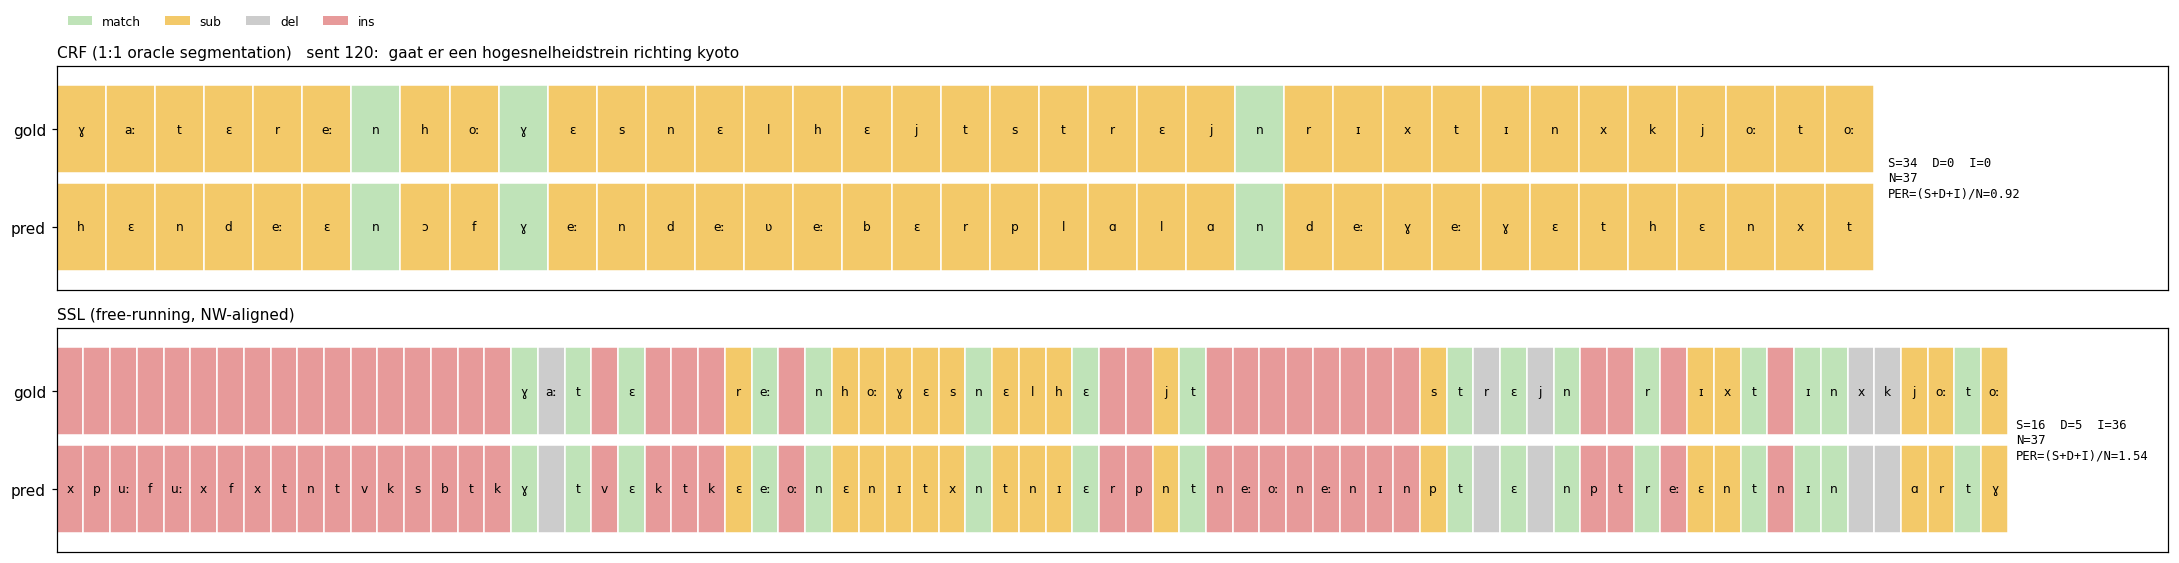

In [72]:
# # %% Cell — WORKED EXAMPLE: same test sentence, both models, PER calculation =====
# from run_pipeline import load_mfa_alignments
# from collections import Counter
# from matplotlib.patches import Patch

# PID = 'P22'
# mfa = load_mfa_alignments(PID)

# def sent_seq(d, sid):
#     tl, pl = np.asarray(d['true_labels']), np.asarray(d['predictions'])
#     ts, ps = np.asarray(d['true_sentence_ids']), np.asarray(d['pred_sentence_ids'])
#     return list(tl[ts == sid]), list(pl[ps == sid])

# common = sorted(set(np.asarray(crf_export[PID]['true_sentence_ids']).tolist()) &
#                 set(np.asarray(ssl_results[PID]['true_sentence_ids']).tolist()))

# print(f"{PID}: sentences in BOTH test sets:", common)

# SID  = common[0]                       # <- change to taste
# words = [w for w in dict.fromkeys(ph['word'] for ph in mfa.get(SID, [])) if w]
# gold, crf_pred = sent_seq(crf_export[PID], SID)
# _,    ssl_pred = sent_seq(ssl_results[PID], SID)

# def aligned_ops(gold, pred, one_to_one=False):
#     if one_to_one:                                     # CRF: 1:1, only match/sub
#         return [(g, p, 'match' if g == p else 'sub') for g, p in zip(gold, pred)]
#     ops = []                                           # SSL: NW, full S/D/I
#     for g, p in needleman_wunsch(gold, pred):
#         ops.append((g, p, 'ins' if g is None else 'del' if p is None
#                     else 'match' if g == p else 'sub'))
#     return ops

# COL = {'match': '#bfe3b8', 'sub': '#f3c969', 'del': '#cccccc', 'ins': '#e79a9a'}
# def draw_align(ax, ops, title):
#     for i, (g, p, op) in enumerate(ops):
#         for y in (0, 1):
#             ax.add_patch(plt.Rectangle((i, y), 1, 0.9, facecolor=COL[op], edgecolor='w'))
#         ax.text(i + .5, 1.45, '' if g is None else g, ha='center', va='center', fontsize=8)
#         ax.text(i + .5, 0.45, '' if p is None else p, ha='center', va='center', fontsize=8)
#     c = Counter(op for *_, op in ops)
#     S, D, I = c['sub'], c['del'], c['ins']
#     N = sum(1 for g, *_ in ops if g is not None)
#     ax.text(len(ops) + 0.3, 0.95,
#             f"S={S}  D={D}  I={I}\nN={N}\nPER=(S+D+I)/N={(S+D+I)/N:.2f}",
#             ha='left', va='center', fontsize=8, family='monospace')
#     ax.set_xlim(0, len(ops) + 6); ax.set_ylim(-0.2, 2.1)
#     ax.set_yticks([0.45, 1.45]); ax.set_yticklabels(['pred', 'gold'])
#     ax.set_xticks([]); ax.set_title(title, loc='left', fontsize=10)

# ops_crf = aligned_ops(gold, crf_pred, one_to_one=True)
# ops_ssl = aligned_ops(gold, ssl_pred, one_to_one=False)
# W = max(len(ops_crf), len(ops_ssl))
# fig, axes = plt.subplots(2, 1, figsize=(min(20, 0.33 * W + 4), 5.2))
# draw_align(axes[0], ops_crf, f"CRF (1:1 oracle segmentation)   sent {SID}:  {' '.join(words)}")
# draw_align(axes[1], ops_ssl, "SSL (free-running, NW-aligned)")
# axes[0].legend(handles=[Patch(facecolor=COL[k], label=k) for k in ('match','sub','del','ins')],
#                ncol=4, loc='lower left', bbox_to_anchor=(0, 1.12), fontsize=8, frameon=False)
# plt.tight_layout(); savefig('fig_worked_example.png'); plt.show()

C:\Temp\ipykernel_7596\1865886723.py:22: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  return np.divide(M, s, where=s > 0)               # row-normalise: P(pred | gold)
C:\Temp\ipykernel_7596\1865886723.py:22: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  return np.divide(M, s, where=s > 0)               # row-normalise: P(pred | gold)


saved fig_consonant_confusion.png


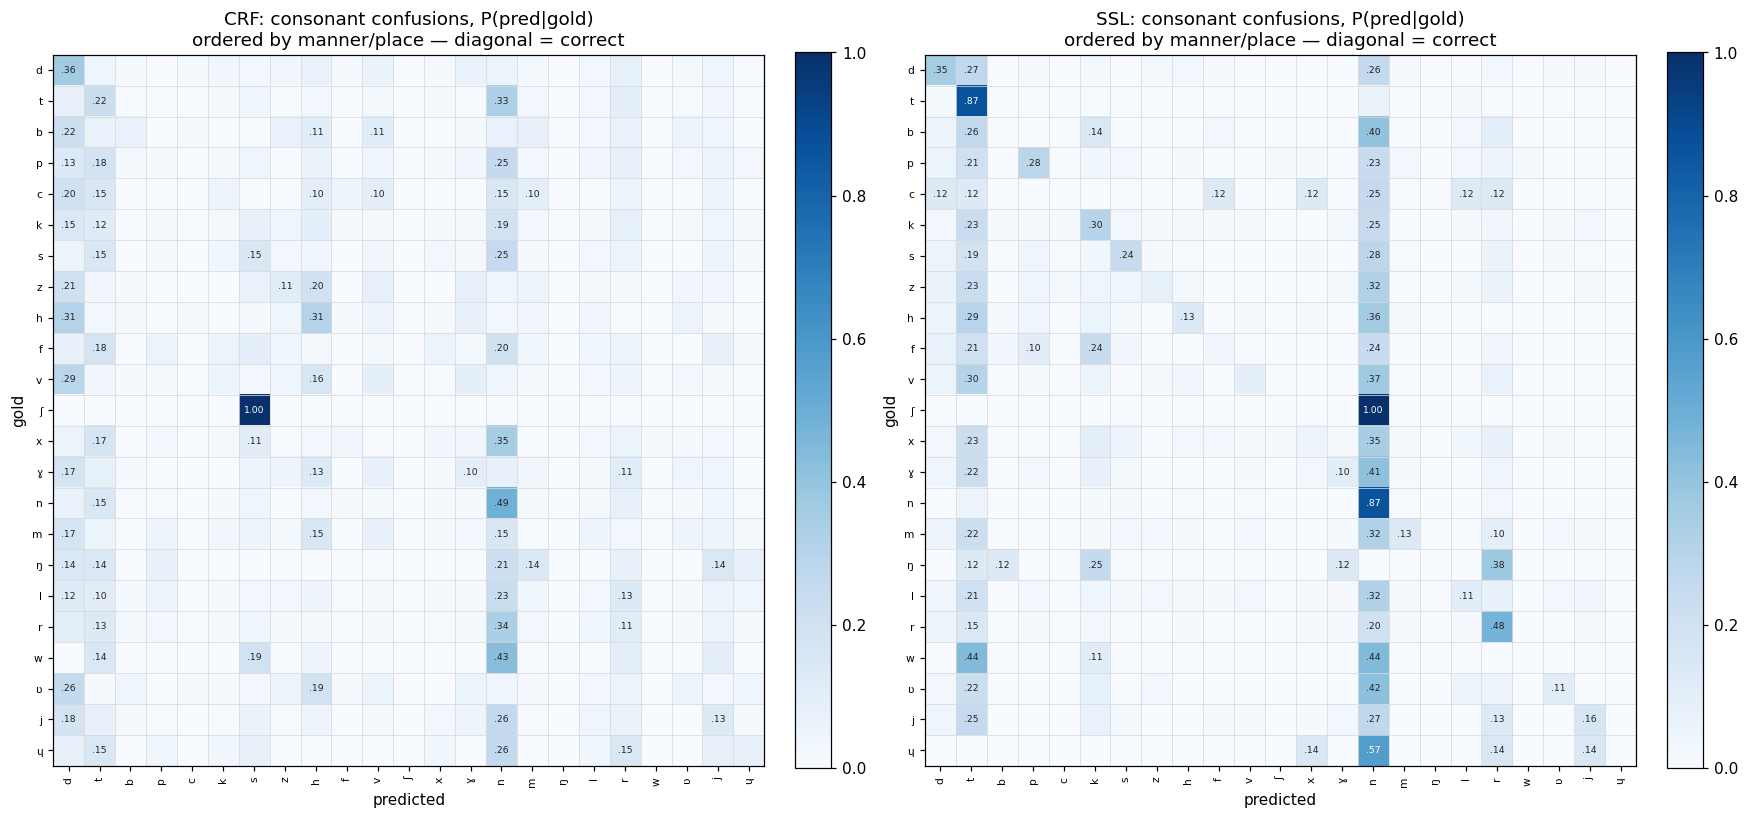

Top off-diagonal consonant confusions (gold→pred, count):
  CRF: t→n(170), r→n(112), n→t(85), s→n(66), t→r(48), j→n(44), v→d(43), r→t(42)
  SSL: r→n(40), s→n(38), l→n(38), d→t(33), d→n(32), r→t(30), x→n(29), ɣ→n(28)


In [20]:
# %% Cell — CONSONANT CONFUSION MATRICES (CRF vs SSL) ===========================
def conf_counts(aligned_fn, results):
    cnt = Counter()
    for pid in pids:
        for g, p in aligned_fn(results[pid]):
            if is_cons(g) and is_cons(p):
                cnt[(g, p)] += 1
    return cnt

cc = conf_counts(aligned_pairs_zip, crf_export)   # CRF 1:1 (incl. correct on diagonal)
sc = conf_counts(aligned_pairs_nw,  ssl_results)  # SSL NW

mord = {'plosive': 0, 'fricative': 1, 'nasal': 2, 'approx': 3}
cons = sorted({c for (g, p) in list(cc) + list(sc) for c in (g, p)},
              key=lambda c: (mord.get(manner(c), 9), str(place(c)), c))
idx = {c: i for i, c in enumerate(cons)}; n = len(cons)

def matrix(cnt):
    M = np.zeros((n, n))
    for (g, p), v in cnt.items(): M[idx[g], idx[p]] += v
    s = M.sum(1, keepdims=True)
    return np.divide(M, s, where=s > 0)               # row-normalise: P(pred | gold)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
for ax, (nm, cnt) in zip(axes, [('CRF', cc), ('SSL', sc)]):
    M = matrix(cnt)
    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(cons, fontsize=7, rotation=90)
    ax.set_yticks(range(n)); ax.set_yticklabels(cons, fontsize=7)
    ax.set_xlabel('predicted'); ax.set_ylabel('gold')
    ax.set_title(f'{nm}: consonant confusions, P(pred|gold)\n'
                 'ordered by manner/place — diagonal = correct')
    # annotate salient cells; dark text on light cells, white text on dark cells
    for i in range(n):
        for j in range(n):
            v = M[i, j]
            if v >= 0.10:
                ax.text(j, i, f'{v:.2f}'.lstrip('0'), ha='center', va='center',
                        fontsize=6, color='white' if v > 0.55 else '#222')
    # light gridlines to separate cells
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', color='0.85', lw=0.5)
    ax.tick_params(which='minor', length=0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); savefig('fig_consonant_confusion.png'); plt.show()

print("Top off-diagonal consonant confusions (gold→pred, count):")
for nm, cnt in [('CRF', cc), ('SSL', sc)]:
    errs = sorted(((v, g, p) for (g, p), v in cnt.items() if g != p), reverse=True)
    print(f"  {nm}:", ', '.join(f'{g}→{p}({v})' for v, g, p in errs[:8]))

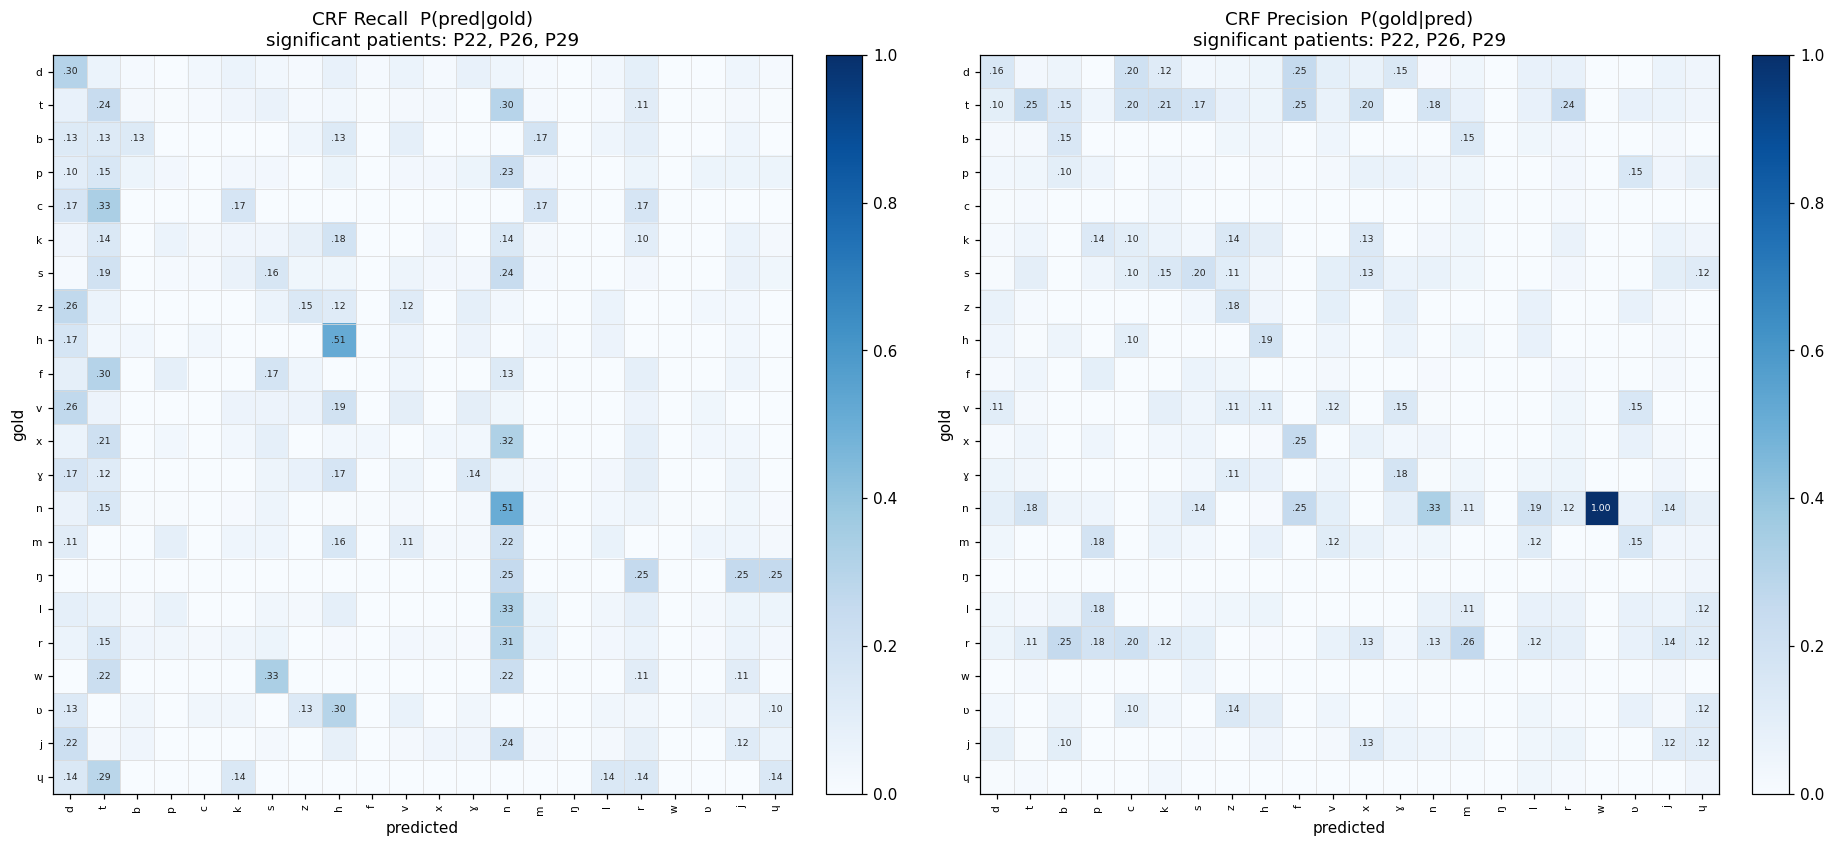

mean recall diagonal (sig patients): 0.160
  d   R=0.30 P=0.16 F1=0.21 (n=66)
  t   R=0.24 P=0.25 F1=0.25 (n=169)
  b   R=0.13 P=0.15 F1=0.14 (n=23)
  p   R=0.03 P=0.05 F1=0.03 (n=39)
  c   R=0.00 P=0.00 F1=0.00 (n=6)
  k   R=0.04 P=0.06 F1=0.05 (n=49)
  s   R=0.16 P=0.20 F1=0.18 (n=80)
  z   R=0.15 P=0.18 F1=0.16 (n=34)
  h   R=0.51 P=0.19 F1=0.28 (n=35)
  f   R=0.00 P=0.00 F1=0.00 (n=23)
  v   R=0.09 P=0.12 F1=0.10 (n=53)
  x   R=0.03 P=0.07 F1=0.04 (n=34)
  ɣ   R=0.14 P=0.18 F1=0.16 (n=42)
  n   R=0.51 P=0.33 F1=0.40 (n=182)
  m   R=0.00 P=0.00 F1=0.00 (n=45)
  ŋ   R=0.00 P=0.00 F1=0.00 (n=4)
  l   R=0.03 P=0.08 F1=0.05 (n=58)
  r   R=0.06 P=0.09 F1=0.07 (n=117)
  w   R=0.00 P=0.00 F1=0.00 (n=9)
  ʋ   R=0.03 P=0.08 F1=0.05 (n=30)
  j   R=0.12 P=0.12 F1=0.12 (n=51)
  ɥ   R=0.14 P=0.04 F1=0.06 (n=7)


In [22]:
# %% CRF confusion — permutation-significant patients only ======================
import numpy as np, matplotlib.pyplot as plt
from collections import Counter
import importlib, phon_helpers; importlib.reload(phon_helpers)
from phon_helpers import manner, place, is_cons, aligned_pairs_zip

SIG_PIDS  = ['P22', 'P26', 'P29']     # order-7 permutation p<0.05
CONS_ONLY = True                      # set False to include vowels

pairs = Counter()
for pid in SIG_PIDS:
    for g, p in aligned_pairs_zip(crf_export[pid]):        # CRF 1:1 → zip
        if (not CONS_ONLY) or (is_cons(g) and is_cons(p)):
            pairs[(g, p)] += 1

mord = {'plosive':0,'fricative':1,'nasal':2,'approx':3,'vowel':4}
syms = sorted({c for gp in pairs for c in gp}, key=lambda c:(mord.get(manner(c),9), str(place(c)), c))
idx = {c:i for i,c in enumerate(syms)}; n=len(syms)
M = np.zeros((n,n))
for (g,p),v in pairs.items(): M[idx[g],idx[p]] += v
rsum, csum = M.sum(1,keepdims=True), M.sum(0,keepdims=True)
recall = np.divide(M, rsum, out=np.zeros_like(M), where=rsum>0)
prec   = np.divide(M, csum, out=np.zeros_like(M), where=csum>0)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
for ax, Mx, ttl in [(axes[0],recall,'CRF Recall  P(pred|gold)'),(axes[1],prec,'CRF Precision  P(gold|pred)')]:
    im = ax.imshow(Mx, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(syms, fontsize=7, rotation=90)
    ax.set_yticks(range(n)); ax.set_yticklabels(syms, fontsize=7)
    ax.set_xlabel('predicted'); ax.set_ylabel('gold')
    ax.set_title(f'{ttl}\nsignificant patients: {", ".join(SIG_PIDS)}')
    for i in range(n):
        for j in range(n):
            if Mx[i,j] >= 0.10:
                ax.text(j,i,f'{Mx[i,j]:.2f}'.lstrip('0'),ha='center',va='center',
                        fontsize=6,color='white' if Mx[i,j]>0.55 else '#222')
    ax.set_xticks(np.arange(-.5,n,1),minor=True); ax.set_yticks(np.arange(-.5,n,1),minor=True)
    ax.grid(which='minor',color='0.85',lw=0.5); ax.tick_params(which='minor',length=0)
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
plt.tight_layout(); plt.savefig('report/fig_crf_confusion_sig.png',dpi=150,bbox_inches='tight'); plt.show()

dpos = np.diag(M) > 0
print(f"mean recall diagonal (sig patients): {np.nanmean(np.diag(recall)[dpos]):.3f}")
for c in syms:
    i=idx[c]; r=recall[i,i]; p=prec[i,i]; f1=2*r*p/(r+p) if r+p>0 else 0
    print(f"  {c:<3} R={r:.2f} P={p:.2f} F1={f1:.2f} (n={int(M[i].sum())})")

In [97]:
# %% ABLATION 1 — segmentation: placement + COUNT ==============================
import os, numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn_crfsuite import CRF
from scipy.stats import wilcoxon
from run_pipeline import load_mfa_alignments
from extract_features import extractHG
from config import DUTCH_30_PATH
from phon_helpers import needleman_wunsch, edit_distance

cfg = pipeline.config
EEG_SR, WIN, FS = cfg.eeg_sr, cfg.window_length, cfg.frameshift
ORDER    = run_config['stacking_order']
MINSAMP  = int(WIN * EEG_SR) + 1
PADFLOOR = max(MINSAMP, 40)
NPCA     = 50
pids = sorted(crf_results)

def seg_vec(eeg_seg):
    n = eeg_seg.shape[0]
    if n < PADFLOOR: eeg_seg = np.pad(eeg_seg, ((0, PADFLOOR - n), (0, 0)))
    try:
        feat = extractHG(eeg_seg, EEG_SR, windowLength=WIN, frameshift=FS)
    except Exception:
        return None
    if feat is None or feat.shape[0] == 0: return None
    T, C = feat.shape; w = 2 * ORDER + 1
    st = np.zeros((T, C * w), np.float32)
    for t in range(T):
        for k in range(-ORDER, ORDER + 1):
            tt = t + k
            if 0 <= tt < T: st[t, (k + ORDER) * C:(k + ORDER + 1) * C] = feat[tt]
    return st.mean(0)

def patient_eeg(pid):
    raw = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy'))
    pd = pipeline.patient_data.get(pid, {})
    if   'channel_mask' in pd:      raw = raw[:, pd['channel_mask']]
    elif 'included_channels' in pd: raw = raw[:, pd['included_channels']]
    return raw

def sent_spans(pid):
    wd = pipeline.split_result['word_segments_dict'][pid]
    return {i: (s['stim_start_idx'], s['stim_end_idx'])
            for i, s in enumerate(wd['sentence_list']) if isinstance(s, dict) and s.get('text')}

def crf_feat(row): return {f'f{j}': float(v) for j, v in enumerate(row)}

def nw_dist(a, b):                       # S+D+I from the same NW alignment as PER/WER
    S = D = I = 0
    for x, y in needleman_wunsch(list(a), list(b)):
        if x is not None and y is not None: S += (x != y)
        elif y is None: D += 1
        else:           I += 1
    return S + D + I

def fit_clf(X, y, grp):
    keep = {c for c, n in Counter(y).items() if n >= 5}
    m = np.isin(y, list(keep)); X, y, grp = X[m], y[m], grp[m]
    sc  = StandardScaler().fit(X)
    pca = PCA(min(NPCA, X.shape[1], X.shape[0])).fit(sc.transform(X))
    Xp  = pca.transform(sc.transform(X))
    seqs, labs = [], []
    for sid in sorted(set(grp)):
        idx = np.where(grp == sid)[0]
        seqs.append([crf_feat(Xp[i]) for i in idx]); labs.append([y[i] for i in idx])
    clf = CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True)
    clf.fit(seqs, labs)
    return sc, pca, clf

def build_train(pid, mfa, spans, raw, test_sids):
    X, y, grp = [], [], []
    for sid, phs in mfa.items():
        if sid in test_sids or sid not in spans: continue
        a, b = spans[sid]; seeg = raw[a:b]
        for ph in phs:
            s = max(0, int(ph['start_s'] * EEG_SR)); e = min(seeg.shape[0], int(ph['end_s'] * EEG_SR))
            if e <= s: continue
            v = seg_vec(seeg[s:e])
            if v is not None: X.append(v); y.append(ph['phone']); grp.append(sid)
    return np.array(X, np.float32), np.array(y), np.array(grp)

def predict_seq(sc, pca, clf, seeg, intervals):
    vs = []
    for (s, e) in intervals:
        a = max(0, int(s * EEG_SR)); b = min(seeg.shape[0], int(e * EEG_SR))
        v = seg_vec(seeg[a:b]) if b > a else None
        if v is not None: vs.append(v)
    if not vs: return []
    Xp = pca.transform(sc.transform(np.array(vs, np.float32)))
    return clf.predict([[crf_feat(r) for r in Xp]])[0]

def edges_to_intervals(edges): return list(zip(edges[:-1], edges[1:]))

rng = np.random.default_rng(0)
ratios = [0.7, 1.3, 1.7]                          # wrong-count, uniform placement
conds  = ['oracle', 'uniform', 'random'] + [f'unif{r}' for r in ratios]
per = {c: {} for c in conds}
for pid in pids:
    mfa = load_mfa_alignments(pid); spans = sent_spans(pid); raw = patient_eeg(pid)
    test_sids = set(np.asarray(crf_results[pid]['true_sentence_ids']).tolist())
    sc, pca, clf = fit_clf(*build_train(pid, mfa, spans, raw, test_sids))
    eds = {c: 0 for c in conds}; gl = 0
    for sid in sorted(test_sids):
        if sid not in spans or sid not in mfa: continue
        a, b = spans[sid]; seeg = raw[a:b]
        gold = [ph['phone'] for ph in mfa[sid]]; N = len(gold); gl += N
        lo, hi = mfa[sid][0]['start_s'], mfa[sid][-1]['end_s']
        iv = {'oracle':  [(ph['start_s'], ph['end_s']) for ph in mfa[sid]],
              'uniform': edges_to_intervals(np.linspace(lo, hi, N + 1)),
              'random':  edges_to_intervals(np.concatenate([[lo], np.sort(rng.uniform(lo, hi, max(N-1, 0))), [hi]]))}
        for r in ratios:
            M = max(1, int(round(N * r)))
            iv[f'unif{r}'] = edges_to_intervals(np.linspace(lo, hi, M + 1))
        for c in conds:
            eds[c] += nw_dist(gold, predict_seq(sc, pca, clf, seeg, iv[c]))
    for c in conds: per[c][pid] = eds[c] / max(gl, 1)
    print(f"{pid}: " + "  ".join(f"{c}={per[c][pid]:.3f}" for c in conds))

print("\nmean PER:")
for c in conds: print(f"  {c:<9} {np.mean(list(per[c].values())):.3f}")
oa = np.array([per['oracle'][p] for p in pids]); un = np.array([per['uniform'][p] for p in pids])
ov = np.array([per['unif1.7'][p] for p in pids])
print(f"\nplacement (oracle→uniform):   Δ={np.mean(un-oa):+.3f}  p={wilcoxon(oa, un).pvalue:.4g}")
print(f"count/over-gen (uniform→×1.7): Δ={np.mean(ov-un):+.3f}  p={wilcoxon(un, ov).pvalue:.4g}")

P21: oracle=0.845  uniform=0.884  random=0.863  unif0.7=0.826  unif1.3=1.045  unif1.7=1.373
P22: oracle=0.841  uniform=0.867  random=0.841  unif0.7=0.811  unif1.3=1.044  unif1.7=1.369
P23: oracle=0.850  uniform=0.874  random=0.856  unif0.7=0.817  unif1.3=1.048  unif1.7=1.359
P24: oracle=0.860  uniform=0.896  random=0.876  unif0.7=0.825  unif1.3=1.046  unif1.7=1.368
P25: oracle=0.845  uniform=0.866  random=0.885  unif0.7=0.823  unif1.3=1.014  unif1.7=1.354
P26: oracle=0.850  uniform=0.878  random=0.854  unif0.7=0.805  unif1.3=1.035  unif1.7=1.335
P27: oracle=0.847  uniform=0.867  random=0.837  unif0.7=0.799  unif1.3=1.035  unif1.7=1.343
P28: oracle=0.828  uniform=0.853  random=0.868  unif0.7=0.801  unif1.3=1.028  unif1.7=1.382
P29: oracle=0.840  uniform=0.869  random=0.854  unif0.7=0.784  unif1.3=1.053  unif1.7=1.372
P30: oracle=0.851  uniform=0.887  random=0.864  unif0.7=0.815  unif1.3=1.044  unif1.7=1.369

mean PER:
  oracle    0.846
  uniform   0.874
  random    0.860
  unif0.7   0.8

##### Class rebalancing

In [107]:
import pickle, numpy as np
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from phon_helpers import gather_sequences, needleman_wunsch
from scipy.stats import ttest_1samp

crf = pickle.load(open('results/crf_export.pkl', 'rb'))
ssl = pickle.load(open('results/ssl_results_crfsplit.pkl', 'rb'))

def aligned_pairs(out):                         # NW-aligned (gold,pred) where both exist
    gp, pp = gather_sequences(out); G, P = [], []
    for sid in sorted(set(gp) | set(pp)):
        for a, b in needleman_wunsch(gp.get(sid, []), pp.get(sid, [])):
            if a is not None and b is not None:
                G.append(a); P.append(b)
    return np.array(G), np.array(P)

def report(results, name):
    rows = []
    for pid, out in results.items():
        G, P = aligned_pairs(out)
        if len(G) == 0: continue
        K = len(set(G))
        rows.append((pid,
                     accuracy_score(G, P),                          # raw (prior-inflated)
                     balanced_accuracy_score(G, P),                 # macro recall (rebalanced)
                     1.0 / K,                                       # chance = 1/K
                     balanced_accuracy_score(G, P, adjusted=True))) # 0 = chance, 1 = perfect
    A = np.array([r[1:] for r in rows])
    print(f"\n=== {name} ===")
    for pid, raw, bal, ch, adj in rows:
        print(f"  {pid}: raw {raw:.3f} | balanced {bal:.3f} | chance {ch:.3f} | adj {adj:+.3f}")
    print(f"  COHORT raw {A[:,0].mean():.3f} | balanced {A[:,1].mean():.3f} | "
          f"chance {A[:,2].mean():.3f} | adj {A[:,3].mean():+.3f}")
    print(f"  adjusted balanced acc vs chance: mean {A[:,3].mean():+.3f}, "
          f"paired t p={ttest_1samp(A[:,3], 0).pvalue:.3g}")

report(ssl, 'SSL')
report(crf, 'CRF')


=== SSL ===
  P21: raw 0.371 | balanced 0.159 | chance 0.029 | adj +0.135
  P22: raw 0.364 | balanced 0.164 | chance 0.029 | adj +0.139
  P23: raw 0.361 | balanced 0.175 | chance 0.028 | adj +0.152
  P24: raw 0.404 | balanced 0.159 | chance 0.028 | adj +0.135
  P25: raw 0.380 | balanced 0.146 | chance 0.029 | adj +0.121
  P26: raw 0.375 | balanced 0.199 | chance 0.034 | adj +0.171
  P27: raw 0.394 | balanced 0.176 | chance 0.031 | adj +0.150
  P28: raw 0.391 | balanced 0.173 | chance 0.029 | adj +0.149
  P29: raw 0.373 | balanced 0.166 | chance 0.027 | adj +0.142
  P30: raw 0.390 | balanced 0.184 | chance 0.029 | adj +0.160
  COHORT raw 0.380 | balanced 0.170 | chance 0.029 | adj +0.145
  adjusted balanced acc vs chance: mean +0.145, paired t p=1.19e-10

=== CRF ===
  P21: raw 0.306 | balanced 0.151 | chance 0.029 | adj +0.127
  P22: raw 0.343 | balanced 0.175 | chance 0.029 | adj +0.151
  P23: raw 0.331 | balanced 0.168 | chance 0.028 | adj +0.144
  P24: raw 0.356 | balanced 0.175 | 

In [108]:
from collections import Counter
from run_pipeline import load_mfa_alignments
from phon_helpers import place, manner          # feature mappings used in the analyses

pids = [f'P{i}' for i in range(21, 31)]          # sentence patients (thesis scope)
allph = Counter()
for pid in pids:
    for sid, phs in load_mfa_alignments(pid).items():
        for ph in phs:
            allph[ph['phone']] += 1

print("total phoneme tokens:", sum(allph.values()))          # claim: >23,000
print("inventory size      :", len(allph))
print("full inventory      :", sorted(allph))
print()
# claim 1: no schwa
print("schwa /ə/ count     :", allph.get('ə', 0), "  (claim: 0)")
# claim 3: short open vowel as central /a/ (15) vs back /ɑ/
print("/a/ count           :", allph.get('a', 0), "  (claim: 15)")
print("/ɑ/ count           :", allph.get('ɑ', 0))
# claim 2: no diphthongs — list any multi-symbol vowels that aren't the long monophthongs
LONG = {'aː','eː','iː','oː','uː','yː','øː'}
print("multi-char vowels   :", [p for p in allph if len(p) > 1 and p not in LONG])
print()
# claim 3 (features): /w/,/ʋ/ labiodental ; /c/,/ɥ/ palatal
for sym in ['w','ʋ','c','ɥ']:
    print(f"  {sym!r}: place={place(sym)!r}  manner={manner(sym)!r}  n={allph.get(sym,0)}")

total phoneme tokens: 31039
inventory size      : 42
full inventory      : ['a', 'aː', 'b', 'c', 'd', 'eː', 'f', 'h', 'i', 'iː', 'j', 'k', 'l', 'm', 'n', 'oː', 'p', 'r', 's', 't', 'u', 'uː', 'v', 'w', 'x', 'y', 'yː', 'z', 'øː', 'ŋ', 'œ', 'ɑ', 'ɔ', 'ɔ̈', 'ɛ', 'ɛ̈', 'ɣ', 'ɥ', 'ɪ', 'ʃ', 'ʋ', 'ʏ']

schwa /ə/ count     : 0   (claim: 0)
/a/ count           : 27   (claim: 15)
/ɑ/ count           : 1205
multi-char vowels   : ['ɔ̈', 'ɛ̈']

  'w': place='labden'  manner='approx'  n=103
  'ʋ': place='labden'  manner='approx'  n=524
  'c': place='pal'  manner='plosive'  n=106
  'ɥ': place='pal'  manner='approx'  n=139


In [109]:
from collections import Counter
print("phonemes with >=25 tokens (cohort):",
      sum(1 for p,n in allph.items() if n >= 25),
      sorted(p for p,n in allph.items() if n >= 25))

phonemes with >=25 tokens (cohort): 36 ['a', 'aː', 'b', 'c', 'd', 'eː', 'f', 'h', 'iː', 'j', 'k', 'l', 'm', 'n', 'oː', 'p', 'r', 's', 't', 'uː', 'v', 'w', 'x', 'yː', 'z', 'øː', 'ŋ', 'œ', 'ɑ', 'ɔ', 'ɛ', 'ɣ', 'ɥ', 'ɪ', 'ʋ', 'ʏ']
